<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

## Chargement des packages 


In [1]:
library(tidyverse)    
library(ggplot2)      
library(corrplot)     
library(FactoMineR)   
library(factoextra)   
library(vcd)          
library(GGally)       
library(moments)      
library(gridExtra)    
library(reshape2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

Loading required package: grid


Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




# Analyse exploratoire des données 

## 1. Chargement et vérification des données 

In [2]:
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)


#### 1.1 Dimensions et aperçu général 

In [3]:
head(df)
cat("Dimensions du dataset: ",dim(df))
anyDuplicated(df$ID_patient)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Dimensions du dataset:  15000 19

[1] 0

Le jeu de données contient bien **15 000 patients** (nombre de ligne) et **19 variables** (nombre de colonne).  
La variable `Patient_ID` est un identifiant unique : elle sera **supprimée** pour l'analyse. On vérifie que la colonne Patient_ID est a valeur unique avec la commande
**anyDuplicated** retournant 0 si il n'y a pas de doublons.
Les variables qualitatives sont déjà encodées sous forme d'entiers, il faudra les convertir en **facteurs** pour que R les traite correctement.

In [4]:
str(df)
cat("\nValeurs manquantes par variable :\n")
print(colSums(is.na(df)))
df <- df %>% select(-Patient_ID)

'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_Consumption    : int  1 0 0 0 1 0 0 1 0 

Aucune valeur manquante n'est détectée dans le jeu de données.  
La variable `Patient_ID` a été supprimée car elle n'apporte aucune information prédictive.

Les variables qualitatives suivantes sont encodées en entiers et doivent être converties en facteurs :

| Variable                   | Encodage                                          |
| -------------------------- | ------------------------------------------------- |
| `Genre`                    | 0 = Femme, 1 = Homme                              |
| `Statut_Tabac`             | 0 = Non-fumeur, 1 = Fumeur                        |
| `Consommation_Alcool`      | 0 = Aucune, 1 = Modérée, 2 = Élevée               |
| `Niveau_Activité_Physique` | 0 = Aucun, 1 = Faible, 2 = Modéré, 3 = Élevé |
| `Antécédents_Familiaux`    | 0 = Non, 1 = Oui                                  |
| `Risque_Maladie_Cardiaque` | 0 = Risque faible, 1 = Risque élevé               |


#### 1.2 Conversion des variables qualitatives

In [5]:
df[,"Smoking_Status"]<- as.factor(df[,"Smoking_Status"])
df[,"Gender"]<- as.factor(df[,"Gender"])
df[,"Family_History"]<- as.factor(df[,"Family_History"])
df[,"Heart_Disease_Risk"]<- as.factor(df[,"Heart_Disease_Risk"])
df[,"Alcohol_Consumption"]<- as.factor(df[,"Alcohol_Consumption"])
df[,"Physical_Activity_Level"]<- as.factor(df[,"Physical_Activity_Level"])

#### 1.3 Statistique descriptive 

In [6]:
summary(df)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  

##### 1.3.1 Statistque unidimensionnelle

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


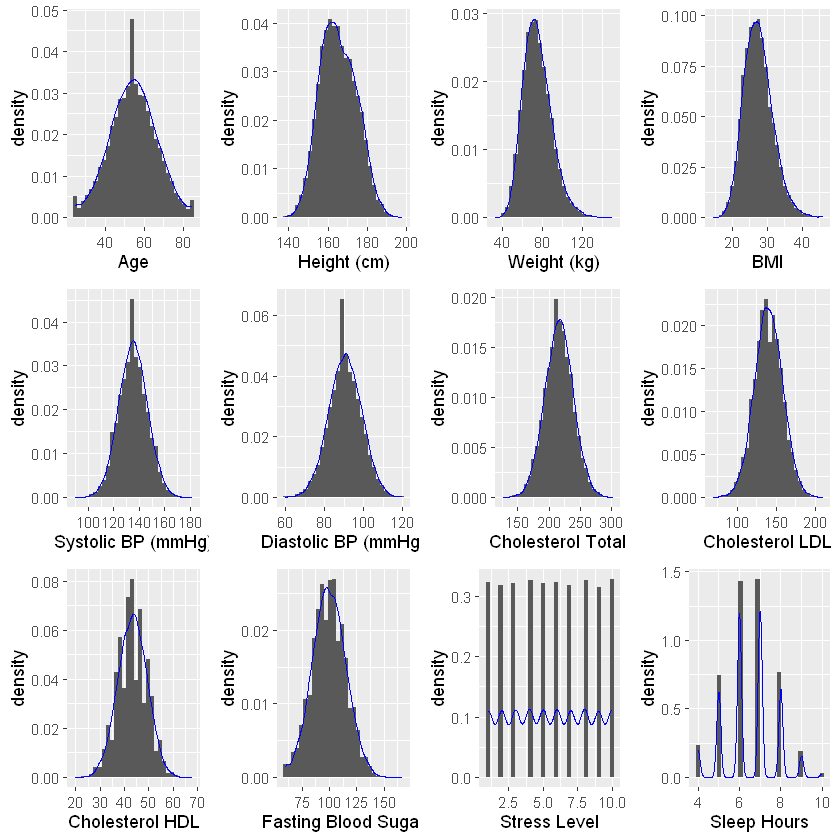

In [7]:
g1  <- ggplot(df, aes(x=df[,"Age"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Age")              
g2  <- ggplot(df, aes(x=df[,"Height_cm"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Height (cm)")      
g3  <- ggplot(df, aes(x=df[,"Weight_kg"]))         + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Weight (kg)")      
g4  <- ggplot(df, aes(x=df[,"BMI"]))               + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("BMI")               
g5  <- ggplot(df, aes(x=df[,"Systolic_BP"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Systolic BP (mmHg)") 
g6  <- ggplot(df, aes(x=df[,"Diastolic_BP"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Diastolic BP (mmHg)")
g7  <- ggplot(df, aes(x=df[,"Cholesterol_Total"])) + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol Total")  
g8  <- ggplot(df, aes(x=df[,"Cholesterol_LDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol LDL")   
g9  <- ggplot(df, aes(x=df[,"Cholesterol_HDL"]))   + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Cholesterol HDL")    
g10 <- ggplot(df, aes(x=df[,"Fasting_Blood_Sugar"]))+ geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Fasting Blood Sugar")
g11 <- ggplot(df, aes(x=df[,"Stress_Level"]))      + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Stress Level")       
g12 <- ggplot(df, aes(x=df[,"Sleep_Hours"]))       + geom_histogram(aes(y=..density..)) + geom_density(alpha=.2, col="blue") + xlab("Sleep Hours")        
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12, ncol=4)
rm(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12)

- `Age`, `Height_cm`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `Fasting_Blood_Sugar` et `BMI` présentent des distributions quasi-symétriques, proches d'une loi normale. Aucune transformation ne semble nécessaire pour ces variables.
- `Weight_kg` et `Cholesterol_HDL` présentent une légère asymétrie à gauche, mais elle reste suffisamment modérée pour ne pas justifier une transformation logarithmique.
- `Stress_Level` et `Sleep_Hours` ont des distributions discrètes et quasi-uniformes, ce sont des variables d'échelle entière (1 à 10 et 4 à 10), ce qui explique l'aspect en "peigne" de leurs histogrammes. Ces variables ne suivent pas une loi normale.


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."


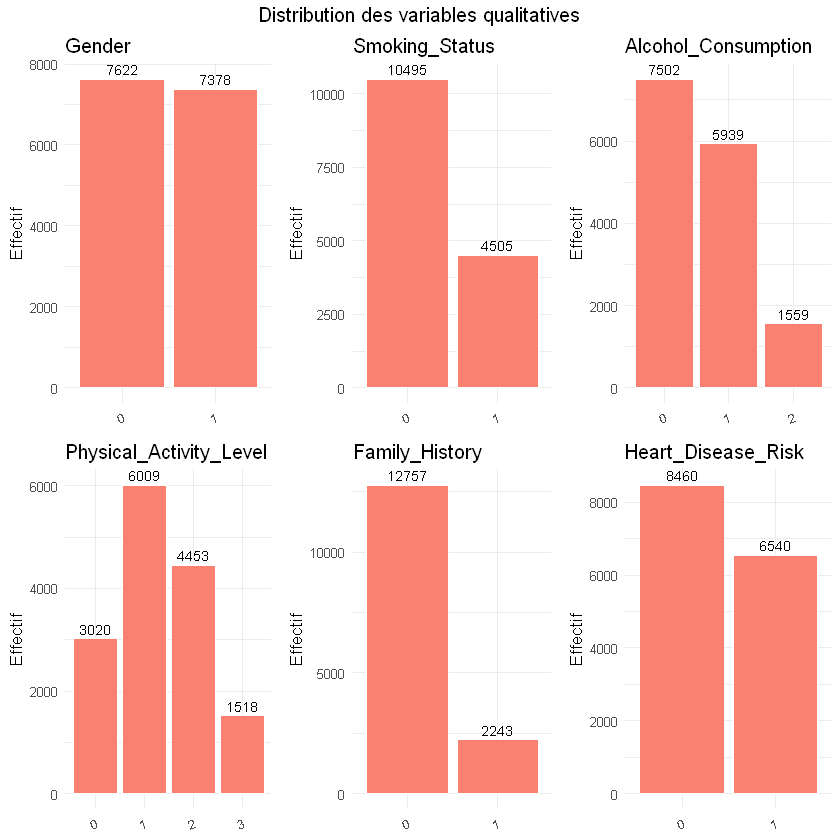

In [8]:

cat_cols <- c("Gender", "Smoking_Status", "Alcohol_Consumption",
              "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk")

plots_qual <- lapply(cat_cols, function(col) {
  ggplot(df, aes_string(x = col)) +
    geom_bar(fill = "salmon", color = "white") +
    geom_text(stat = "count", aes(label = after_stat(count)),
              vjust = -0.4, size = 3) +
    labs(title = col, x = NULL, y = "Effectif") +
    theme_minimal(base_size = 10) +
    theme(axis.text.x = element_text(angle = 20, hjust = 1))
})

grid.arrange(grobs = plots_qual, ncol = 3,
             top = "Distribution des variables qualitatives")

**Distribution des variables qualitatives**

- `Gender` : répartition équilibrée entre les deux modalités.
- `Smoking_Status` : large majorité de non-fumeurs dans la population étudiée.
- `Alcohol_Consumption` : la modalité 0 (aucune consommation) est majoritaire, suivie de la consommation modérée puis élevée.
- `Physical_Activity_Level` : les quatre niveaux d'activité sont relativement bien répartis, avec une légère surreprésentation des niveaux intermédiaires.
- `Family_History` : les antécédents familiaux de maladie cardiaque concernent une minorité de patients.
- `Heart_Disease_Risk` : environ 43.6% des patients présentent un risque élevé, les classes sont suffisamment équilibrées pour éviter tout problème de déséquilibre majeur en modélisation.

#### Statistique bidimensionnelle

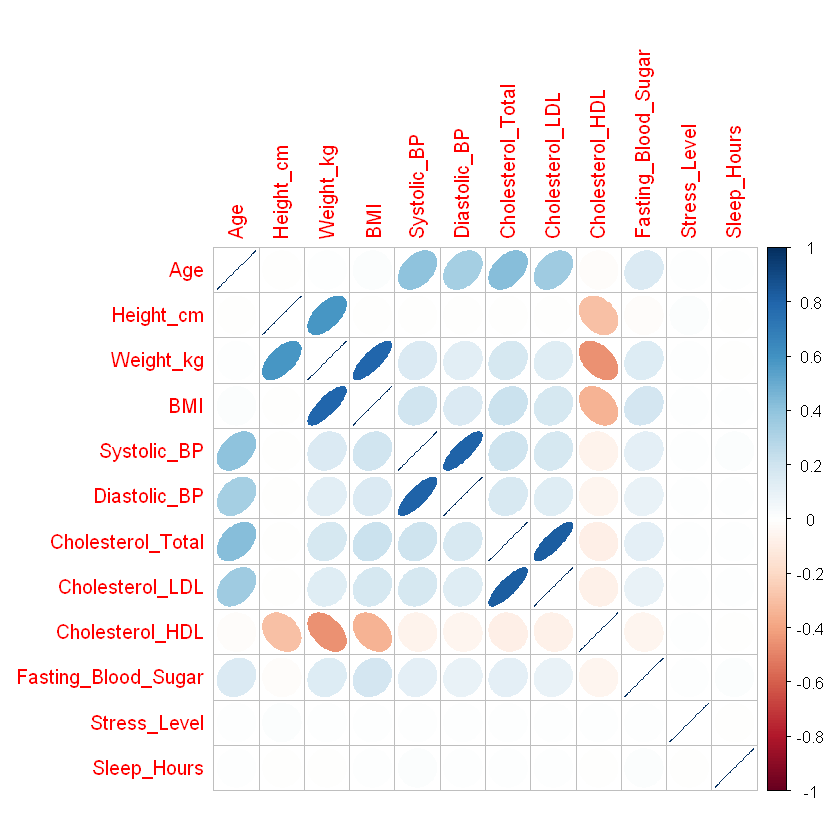

In [9]:
# Regroupement des variables quantitatives dans une matrice 
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP", "Cholesterol_Total",
                "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

# Matrice de corrélation 
corrplot(cor(df[, quant_cols]), method="ellipse")

La corrélation la plus forte et la plus attendue est celle entre `Weight_kg` et `BMI` (corrélation positive très élevée, ellipse très allongée en bleu foncé), ce qui est logique puisque le BMI est directement calculé à partir du poids. On observe également une corrélation positive notable entre `Cholesterol_Total` et `Cholesterol_LDL`, confirmant que le "mauvais" cholestérol constitue la composante principale du cholestérol total, ainsi qu'une corrélation positive entre `Systolic_BP` et `Diastolic_BP`, cohérente médicalement. En revanche, la grande majorité des autres paires de variables présentent des corrélations très faibles voire nulles, ce qui indique une indépendance majoritaire entre les variables.

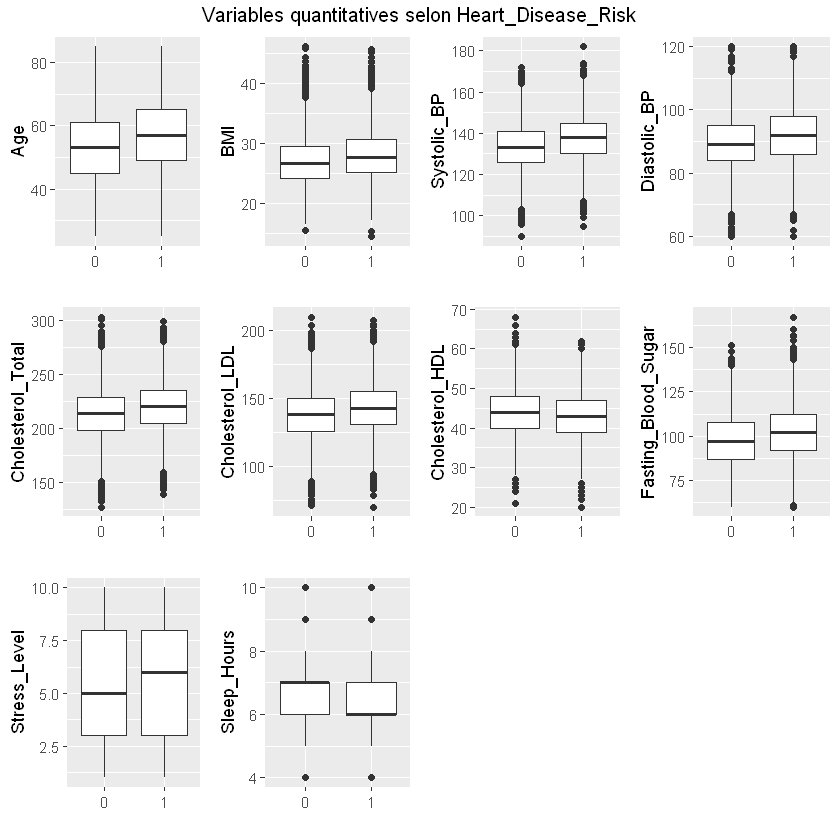

In [10]:
g1  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Age"]))             + geom_boxplot() + xlab("") + ylab("Age")
g2  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "BMI"]))             + geom_boxplot() + xlab("") + ylab("BMI")
g3  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Systolic_BP"]))     + geom_boxplot() + xlab("") + ylab("Systolic_BP")
g4  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Diastolic_BP"]))    + geom_boxplot() + xlab("") + ylab("Diastolic_BP")
g5  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_Total"]))+ geom_boxplot()+ xlab("") + ylab("Cholesterol_Total")
g6  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_LDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_LDL")
g7  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Cholesterol_HDL"])) + geom_boxplot() + xlab("") + ylab("Cholesterol_HDL")
g8  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Fasting_Blood_Sugar"]))+ geom_boxplot()+ xlab("") + ylab("Fasting_Blood_Sugar")
g9  <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Stress_Level"]))    + geom_boxplot() + xlab("") + ylab("Stress_Level")
g10 <- ggplot(df, aes(x = df[, "Heart_Disease_Risk"], y = df[, "Sleep_Hours"]))     + geom_boxplot() + xlab("") + ylab("Sleep_Hours")

grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, ncol = 4,
             top = "Variables quantitatives selon Heart_Disease_Risk")
rm(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10)

`Age` et `Stress_Level` sont les variables qui montrent la différence la plus visible entre les deux groupes, les patients à risque élevé (1) sont en moyenne plus âgés et plus stressés.
`Systolic_BP`, `Cholesterol_LDL` et `Fasting_Blood_Sugar` présentent également une légère tendance à des valeurs plus élevées chez les patients à risque, ce qui est cohérent médicalement. En revanche, `BMI`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_HDL` et `Sleep_Hours` montrent des distributions quasi-identiques entre les deux groupes, suggérant un faible pouvoir discriminant univarié pour ces variables.

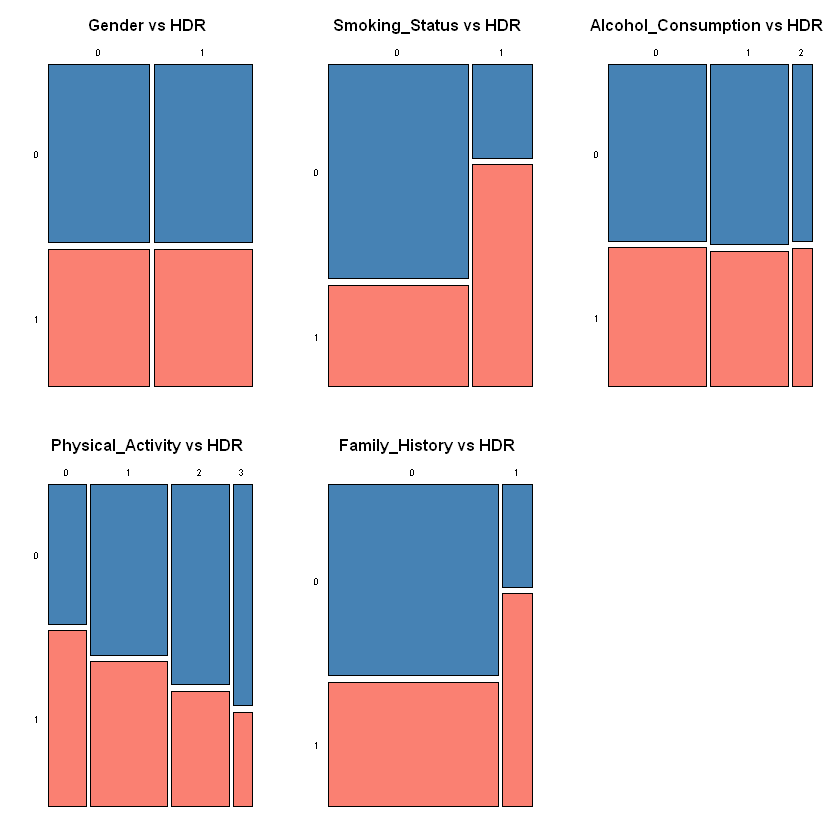

In [11]:
par(mfrow = c(2, 3), mar = c(2, 2, 3, 1))
mosaicplot(table(df[, "Gender"],                 df[, "Heart_Disease_Risk"]),
           main = "Gender vs HDR",                color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Smoking_Status"],          df[, "Heart_Disease_Risk"]),
           main = "Smoking_Status vs HDR",         color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Alcohol_Consumption"],     df[, "Heart_Disease_Risk"]),
           main = "Alcohol_Consumption vs HDR",    color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Physical_Activity_Level"], df[, "Heart_Disease_Risk"]),
           main = "Physical_Activity vs HDR",      color = c("steelblue", "salmon"), las = 1)
mosaicplot(table(df[, "Family_History"],          df[, "Heart_Disease_Risk"]),
           main = "Family_History vs HDR",         color = c("steelblue", "salmon"), las = 1)
par(mfrow = c(1, 1))

- `Gender` et `Alcohol_Consumption` montrent une proportionnalité au niveau des rectangles, révélant ainsi peu de dépendance avec `Heart_Disease_Risk`.
- `Physical_Activity` montre une tendance descendante : l'augmentation du niveau d'activité physique s'accompagne d'une diminution du risque de maladie cardiaque.
- `Family_History` et `Smoking_Status` révèlent une dépendance claire avec `Heart_Disease_Risk`, les patients ayant des antécédents familiaux ou étant fumeurs sont proportionnellement plus à risque élevé.

### Analyse en composante princilpale

L'objectif de l'ACP est de résumer l'information contenue dans les 12 variables quantitatives explicatives en un nombre réduit de composantes principales, tout en conservant un maximum de variance. 



##### Sélection des variables quantitatives


In [12]:
quant_cols <- c("Age", "Height_cm", "Weight_kg", "BMI",
                "Systolic_BP", "Diastolic_BP",
                "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
                "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

df_quant <- df[, quant_cols]

##### Réalisation de l’ACP

Les variables étant exprimées dans des unités différentes, on réalise une ACP réduite (standardisation des variables).

In [13]:
acp <- PCA(df_quant,
           scale.unit = TRUE,
           graph = FALSE)

Ce graphique permet de déterminer combien de composantes principales conserver.




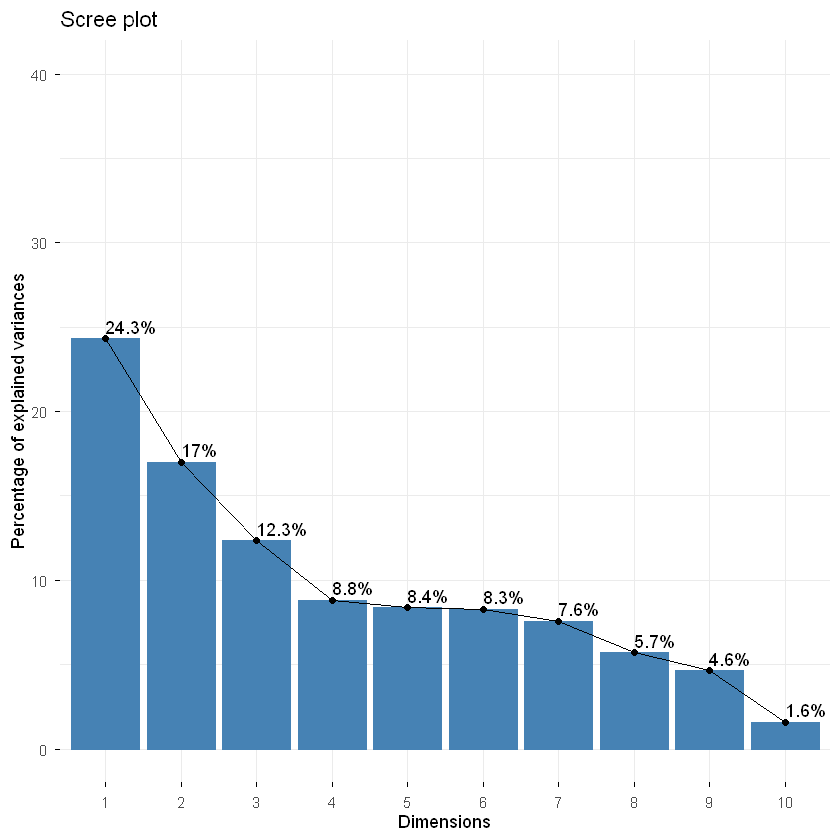

In [14]:
fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))


La décroissance des valeurs propres montre que :

les premières composantes principales expliquent la majorité de la variance

La première dimension explique 24,3% de la variance, la deuxième 17% et la troisième 12,3%.

À elles trois, elles résument 53,6% de l'information totale.

On observe un coude net après la dimension 3.

Nous retiendrons les 3 premières dimensions pour la suite de l'analyse. 


##### Distribution des individus selon les composantes

On observe ici la dispersion des individus dans l’espace des composantes principales.

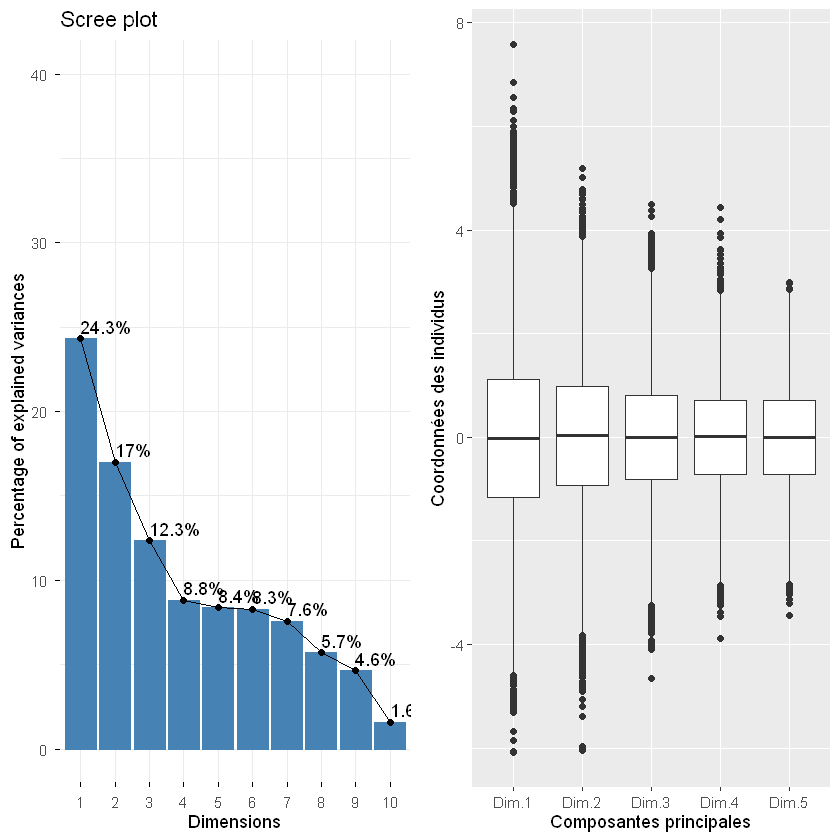

In [15]:
g1 <- fviz_eig(acp, addlabels = TRUE, ylim = c(0,40))

g2 <- ggplot(melt(acp$ind$coord), aes(x = Var2, y = value)) +
  geom_boxplot() +
  xlab("Composantes principales") +
  ylab("Coordonnées des individus")

grid.arrange(g1, g2, ncol = 2)

Ce graphique permet de visualiser :

la dispersion des individus selon chaque composante

La dispersion des individus (boxplot) semble homogène, sans valeurs atypiques extrêmes écrasant les axes, ce qui suggère l’absence de valeurs aberrantes majeures dans les données.

##### Structure de corrélation des variables


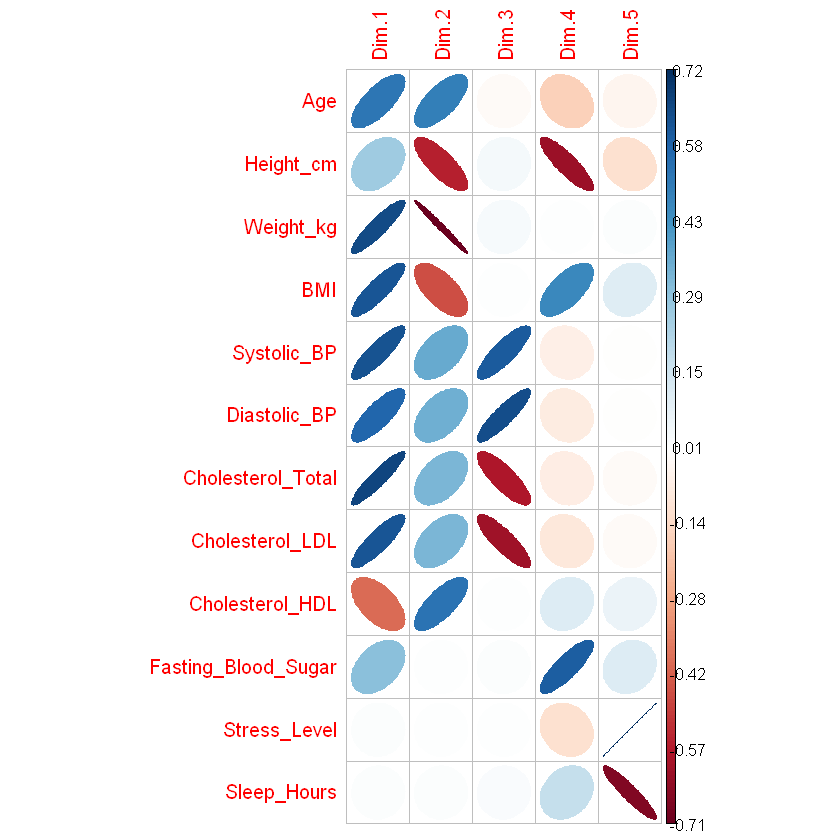

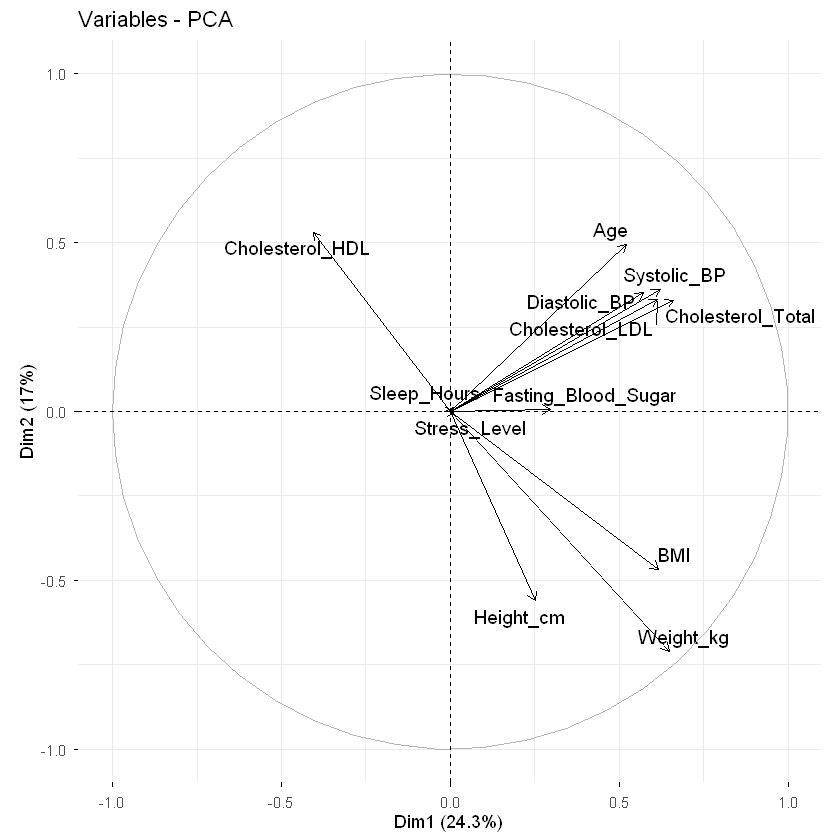

In [16]:
# Matrice de corrélation entre variables et composantes principales
corrplot(acp$var$cor, is.corr = FALSE, method = "ellipse")

# Cercle des corrélations (Dimensions 1 et 2)
fviz_pca_var(acp, axes = c(1, 2), repel = TRUE)

Ce graphique représente les corrélations entre les variables initiales et les composantes principales. La proximité des variables par rapport au cercle extérieur indique qu'elles sont bien représentées par ce premier plan factoriel.

L'Axe 1 (24.3%) : Il définit un axe de "Morphologie et Lipides". On y observe une forte corrélation positive entre le poids (Weight_kg), l'IMC (BMI), le Cholesterol_Total et le Cholesterol_LDL. Médicalement, cela confirme que le "mauvais cholestérol" (LDL) est la composante majeure du cholestérol total dans cet échantillon.

Opposition : Le Cholesterol_HDL (bon cholestérol) est situé à l'opposé du LDL sur cet axe, ce qui est médicalement intuitif : un profil lipidique dégradé associe souvent un LDL haut et un HDL bas.

L'Axe 2 (17%) : Il est principalement porté par l'Âge et la Taille (Height_cm). On note que l'âge est presque orthogonal (à 90°) au poids et au BMI, suggérant que dans ce jeu de données synthétiques, la prise de poids ne dépend pas uniquement du vieillissement.

##### Projection des individus et Risque Cardiaque

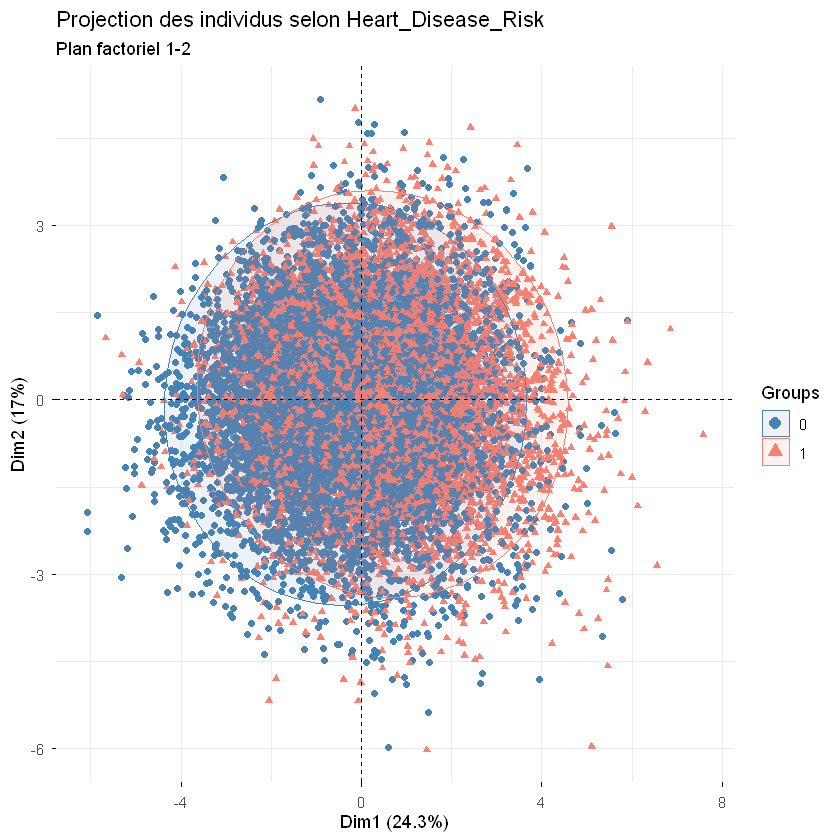

In [17]:
# Projection des individus avec coloration par Heart_Disease_Risk (habillage)
fviz_pca_ind(acp, 
             habillage = df$Heart_Disease_Risk, 
             label = "none", 
             addEllipses = TRUE, 
             palette = c("steelblue", "salmon")) +
  labs(title = "Projection des individus selon Heart_Disease_Risk",
       subtitle = "Plan factoriel 1-2")

Chaque point représente un patient projeté dans l'espace réduit des deux premières composantes. L'objectif est de visualiser si les variables explicatives permettent de séparer naturellement les patients à risque (1) des patients à faible risque (0).

On remarque une absence de clusters distincts. Les deux nuages de points se chevauchent presque intégralement, et leurs ellipses de confiance sont centrées.

Question : Une discrimination linéaire est-elle possible ?
Non, une discrimination linéaire simple par un hyperplan semble impossible à ce stade sur les variables quantitatives seules. Les données présentent une structure continue.

Cela montre que le risque cardiaque est un phénomène multidimensionnel complexe. Une simple règle basée sur le poids ou le cholestérol ne suffit pas à séparer les classes, ce qui justifie le recours ultérieur à des modèles de classification supervisée (Machine Learning) pour prédire Heart_Disease_Risk.

##### Projection selon d'autres axes (Dimensions 1 et 3)

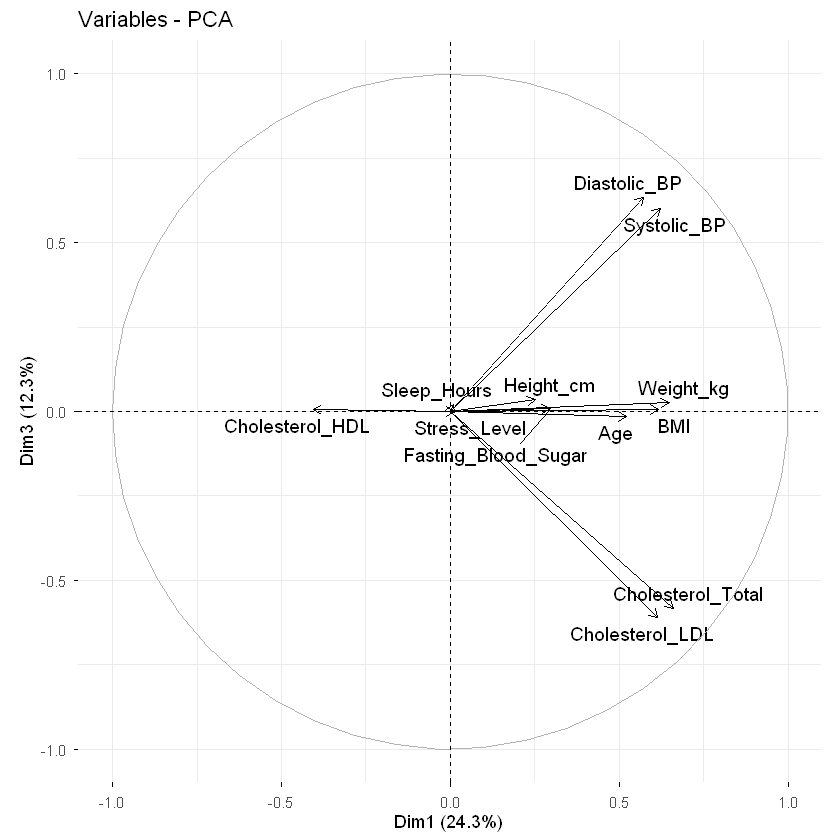

In [18]:
# Cercle des corrélations (Dimensions 1 et 3)
fviz_pca_var(acp, axes = c(1, 3), repel = TRUE)

La projection sur les axes 1 et 3 permet d'identifier des structures de corrélation qui n'étaient pas visibles sur le premier plan factoriel.On constate que les variables de Tension Artérielle (Systolic_BP et Diastolic_BP) sont très fortement corrélées à l'axe 3 ($12.3\%$).Ces variables sont quasi-orthogonales (à $90^\circ$) aux variables de poids et de cholestérol de l'axe 1. Cela signifie que, dans ce jeu de données, l'hypertension artérielle constitue un facteur de risque indépendant de la corpulence ou des lipides. Cette structure est cohérente avec les réalités médicales.

##### Visualisation selon la variable à prédire (Heart_Disease_Risk)

On colore les individus selon Heart_Disease_Risk.



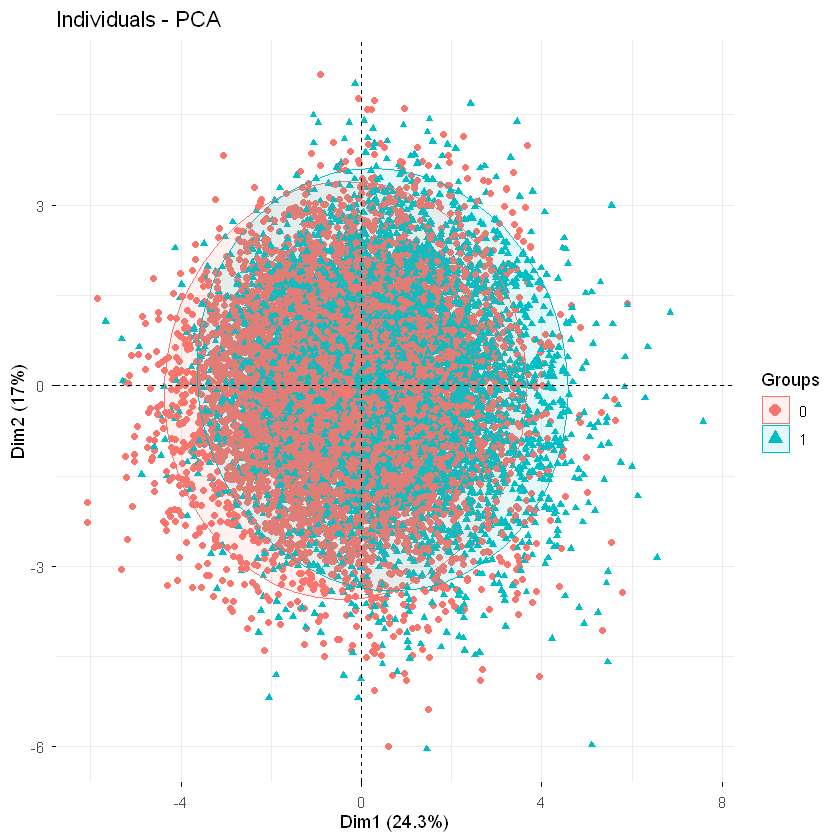

In [19]:
fviz_pca_ind(acp,
             label = "none",
             habillage = df$Heart_Disease_Risk,
             addEllipses = TRUE)    

Cette représentation permet d'évaluer si les deux classes (Risque faible et Risque élevé) sont séparables dans l'espace des composantes principales.

Observation : On constate un chevauchement quasi-total des deux groupes. Les ellipses de confiance sont centrées sur les mêmes zones du plan factoriel.

Conclusion : La séparation entre les classes n'est pas linéairement possible sur les premières composantes. Cela suggère que le risque cardiaque ne dépend pas d'un seul facteur majeur, mais d'une combinaison complexe de variables.

Suite du projet : Ce constat justifie l'utilisation de méthodes de classification plus puissantes (comme la Régression Logistique ou les Forêts Aléatoires) qui seront explorées dans la suite de l'étude.

## Regréssion Logistique

In [20]:
# 1. Charger les données
df <- read.csv("healthcare_synthetic_data.csv")

# 2. Transformer la variable cible
df$Heart_Disease_Risk <- as.factor(df$Heart_Disease_Risk)

# 3. Supprimer Patient_ID
df <- df[, !(names(df) %in% c("Patient_ID"))]

# 4. Train / Test split
set.seed(111)

n <- nrow(df)
train_index <- sample(1:n, size = 0.8*n)

train <- df[train_index, ]
test  <- df[-train_index, ]

# 5. Sous-échantillon (optionnel pour accélérer)
train_small <- train[sample(1:nrow(train), 2000), ]

In [21]:
# Régression logistique sans pénalisation
logit.base <- glm(Heart_Disease_Risk ~ ., 
                   data = train, 
                   family = binomial)

# Prédictions sur le test
prob.base <- predict(logit.base, newdata = test, type = "response")
pred.base <- ifelse(prob.base > 0.5, 1, 0)

# Matrice de confusion
cat("Matrice de confusion :\n")
print(table(pred.base, test[, "Heart_Disease_Risk"]))

# Accuracy
acc.base <- mean(pred.base == test[, "Heart_Disease_Risk"])
cat("Accuracy Test :", round(acc.base, 4), "\n")

Matrice de confusion :
         
pred.base    0    1
        0 1364  518
        1  294  824
Accuracy Test : 0.7293 


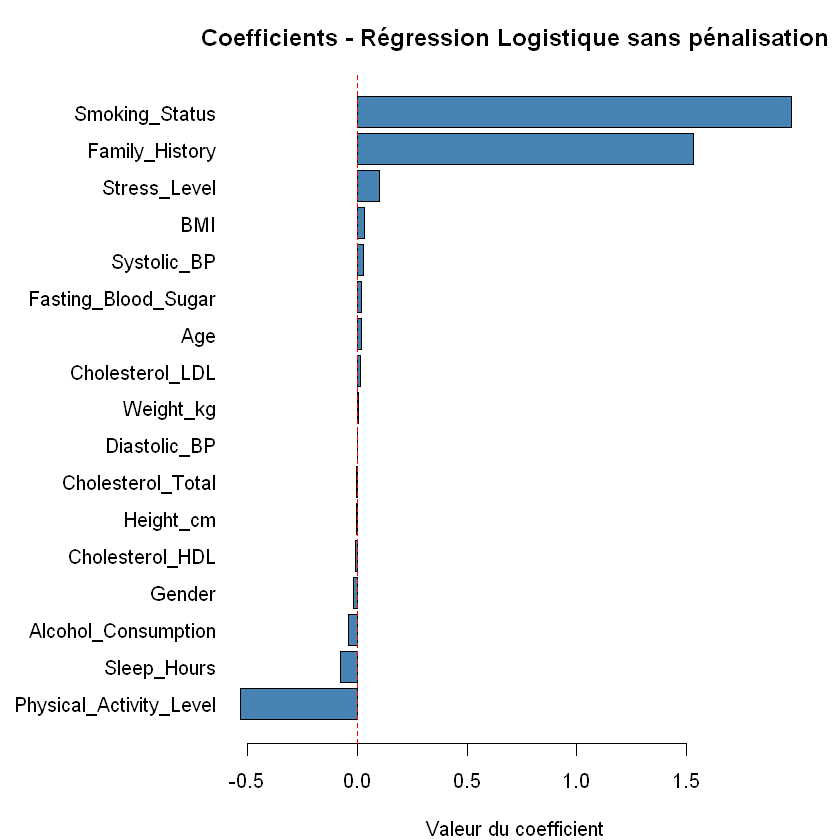

In [22]:
# Coefficients du modèle
coef.base <- coef(logit.base)[-1]
par(mar = c(4, 10, 3, 2))
barplot(sort(coef.base),
        horiz = TRUE,
        las = 1,
        col = "steelblue",
        main = "Coefficients - Régression Logistique sans pénalisation",
        xlab = "Valeur du coefficient")
abline(v = 0, col = "red", lty = 2)

En R, on peut effectuer une sélection automatique de variables via `step()` 
qui utilise le critère **AIC** (Akaike Information Criterion) :

$$AIC = -2\log(\mathcal{L}) + 2k$$

où $k$ est le nombre de paramètres et $\mathcal{L}$ la vraisemblance du modèle.
La méthode **backward** part du modèle complet et supprime une à une les variables 
qui améliorent l'AIC — c'est l'avantage de R par rapport à Python qui n'a pas 
de `step()` natif dans scikit-learn.

In [23]:
# Sélection de variables par AIC - méthode backward
logit.step <- step(logit.base, 
                    direction = "backward",
                    trace = FALSE)

# Variables conservées
cat("Variables conservées :\n")
print(names(coef(logit.step))[-1])
cat("Nombre de variables conservées :", length(coef(logit.step)) - 1, "\n")

# Prédictions
prob.step <- predict(logit.step, newdata = test, type = "response")
pred.step <- ifelse(prob.step > 0.5, 1, 0)

# Matrice de confusion
cat("\nMatrice de confusion :\n")
print(table(pred.step, test[, "Heart_Disease_Risk"]))

# Accuracy
acc.step <- mean(pred.step == test[, "Heart_Disease_Risk"])
cat("Accuracy Test (AIC backward) :", round(acc.step, 4), "\n")

Variables conservées :
 [1] "Age"                     "BMI"                    
 [3] "Systolic_BP"             "Cholesterol_Total"      
 [5] "Cholesterol_LDL"         "Cholesterol_HDL"        
 [7] "Fasting_Blood_Sugar"     "Smoking_Status"         
 [9] "Physical_Activity_Level" "Family_History"         
[11] "Stress_Level"            "Sleep_Hours"            
Nombre de variables conservées : 12 

Matrice de confusion :
         
pred.step    0    1
        0 1367  519
        1  291  823
Accuracy Test (AIC backward) : 0.73 


### Lasso L1


Warning message:
"package 'glmnet' was built under R version 4.5.3"
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10



Lambda optimal (lambda.min) : 7e-04 
Lambda optimal (lambda.1se) : 0.0116 


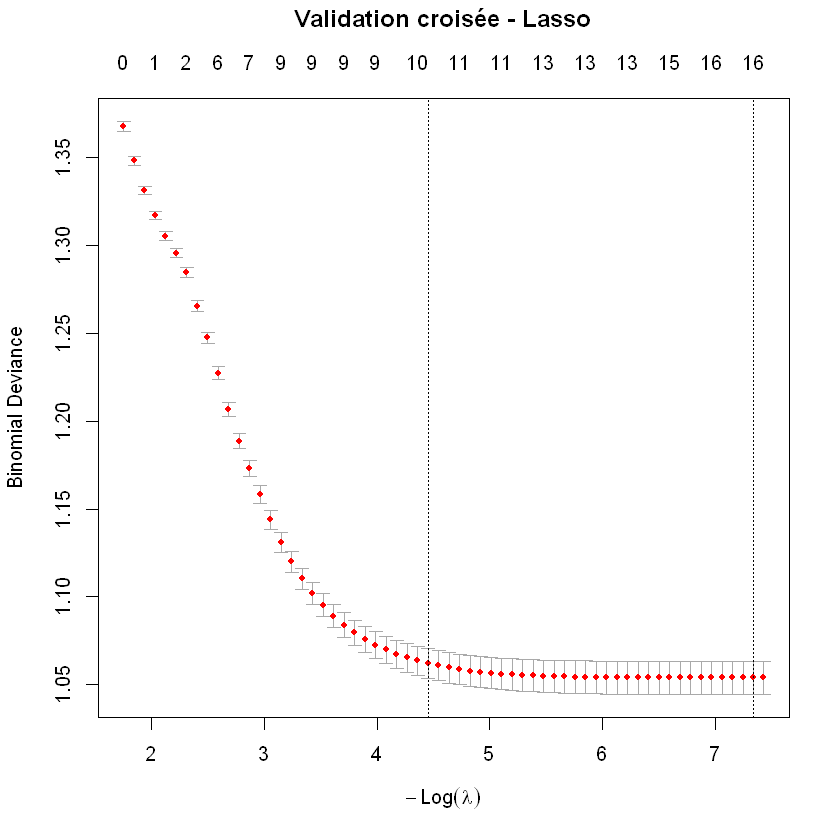

In [24]:
library(glmnet)

# Préparation des matrices (glmnet nécessite des matrices numériques)
X.train <- model.matrix(Heart_Disease_Risk ~ . - 1, data = train)
X.test  <- model.matrix(Heart_Disease_Risk ~ . - 1, data = test)
y.train <- as.numeric(train[, "Heart_Disease_Risk"]) - 1
y.test  <- as.numeric(test[, "Heart_Disease_Risk"]) - 1

# Lasso avec validation croisée (alpha=1 → Lasso)
set.seed(111)
lasso.cv <- cv.glmnet(X.train, y.train,
                       family = "binomial",
                       alpha  = 1,
                       nfolds = 10)

# Lambda optimal
cat("Lambda optimal (lambda.min) :", round(lasso.cv$lambda.min, 4), "\n")
cat("Lambda optimal (lambda.1se) :", round(lasso.cv$lambda.1se, 4), "\n")

# Visualisation
plot(lasso.cv)
title("Validation croisée - Lasso", line = 3)

In [25]:
# Coefficients du modèle Lasso
coef.lasso <- coef(lasso.cv, s = "lambda.min")
print(coef.lasso)

# Variables éliminées
n.zero <- sum(coef.lasso[-1] == 0)
cat("\nVariables éliminées :", n.zero, "\n")
cat("Variables conservées :", length(coef.lasso) - 1 - n.zero, "\n")

# Prédictions
prob.lasso <- predict(lasso.cv,
                       newx = X.test,
                       s    = "lambda.min",
                       type = "response")
pred.lasso <- ifelse(prob.lasso > 0.5, 1, 0)

# Matrice de confusion
cat("\nMatrice de confusion :\n")
print(table(pred.lasso, y.test))

# Accuracy
acc.lasso <- mean(pred.lasso == y.test)
cat("Accuracy Test (Lasso) :", round(acc.lasso, 4), "\n")

18 x 1 sparse Matrix of class "dgCMatrix"
                           lambda.min
(Intercept)             -9.8777102114
Age                      0.0193000723
Gender                  -0.0066634839
Height_cm               -0.0004305741
Weight_kg                .           
BMI                      0.0443343012
Systolic_BP              0.0302654693
Diastolic_BP             0.0015915078
Cholesterol_Total       -0.0014932442
Cholesterol_LDL          0.0113082385
Cholesterol_HDL         -0.0073386304
Fasting_Blood_Sugar      0.0197235790
Smoking_Status           1.9624624807
Alcohol_Consumption     -0.0356338042
Physical_Activity_Level -0.5268719755
Family_History           1.5155613877
Stress_Level             0.1002592239
Sleep_Hours             -0.0713006611

Variables éliminées : 1 
Variables conservées : 16 

Matrice de confusion :
          y.test
pred.lasso    0    1
         0 1366  518
         1  292  824
Accuracy Test (Lasso) : 0.73 


In [26]:
resultats <- data.frame(
  Modele         = c("Sans pénalisation",
                     "Sélection AIC (backward)",
                     "Lasso (lambda.min)"),
  Accuracy_Test  = c(round(acc.base,  4),
                     round(acc.step,  4),
                     round(acc.lasso, 4))
)
print(resultats)

                    Modele Accuracy_Test
1        Sans pénalisation        0.7293
2 Sélection AIC (backward)        0.7300
3       Lasso (lambda.min)        0.7300


# Partie 1 : Prédiction de Heart_Disease_Risk
## 1.1 Modèle Linéaire Généralisé : Régression Logistique

In [27]:
library(glmnet)
library(ggfortify)
library(pROC)
library(ROCR)

# Fonction résidus
gplot.res <- function(x, y, titre = "Résidus") {
    ggplot(data.frame(x=x, y=y), aes(x, y)) +
    geom_point(col = "blue", alpha = 0.4, size = 0.8) +
    ylab("Résidus") + xlab("Valeurs prédites") +
    ggtitle(titre) +
    geom_hline(yintercept = 0, col = "green")
}

# Division Train et Test
set.seed(111)
test.ratio <- 0.2
npop       <- nrow(df)
testi      <- sample(1:npop, ceiling(npop * test.ratio))
appri      <- setdiff(1:npop, testi)

#  Échantillons pour la classification 
datappq0 <- df[appri, ]   # train brut
datestq0 <- df[testi, ]   # test brut

cat("Taille apprentissage :", nrow(datappq0), "\n")
cat("Taille test          :", nrow(datestq0), "\n")

Warning message:
"package 'ggfortify' was built under R version 4.5.3"
Warning message:
"package 'pROC' was built under R version 4.5.3"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var


Warning message:
"package 'ROCR' was built under R version 4.5.3"


Taille apprentissage : 12000 
Taille test          : 3000 


In [28]:
#  Normalisation (comme dans le TP Ozone)
cat_cols <- c("Gender", "Smoking_Status", "Alcohol_Consumption",
              "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk")

# Indices des colonnes quantitatives
quant_idx <- which(!names(df) %in% cat_cols)

# Normalisation du train
datappq <- datappq0
datappq[, quant_idx] <- scale(datappq0[, quant_idx])

# Normalisation du test avec les paramètres du train
datestq <- datestq0
datestq[, quant_idx] <- scale(datestq0[, quant_idx],
    center = sapply(datappq0[, quant_idx], mean),
    scale  = sapply(datappq0[, quant_idx], sd))

summary(datappq)

      Age               Gender         Height_cm          Weight_kg       
 Min.   :-2.46911   Min.   :0.0000   Min.   :-2.91995   Min.   :-2.95670  
 1st Qu.:-0.71488   1st Qu.:0.0000   1st Qu.:-0.74279   1st Qu.:-0.71629  
 Median : 0.03694   Median :0.0000   Median :-0.06788   Median :-0.09554  
 Mean   : 0.00000   Mean   :0.4931   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.70522   3rd Qu.:1.0000   3rd Qu.: 0.73767   3rd Qu.: 0.61796  
 Max.   : 2.54298   Max.   :1.0000   Max.   : 3.53532   Max.   : 5.34851  
      BMI           Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504   Min.   :-3.70977  
 1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311   1st Qu.:-0.67073  
 Median :-0.0753   Median :-0.01033   Median : 0.05535   Median : 0.03397  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573   3rd Qu.: 0.69463  
 Max.   : 4.4984   

Le jeu de données est divisé en **80% apprentissage** (12 000 patients) 
et **20% test** (3 000 patients), avec le même `seed=111` qu'en Python 
pour assurer la comparabilité. La normalisation est calculée uniquement 
sur l'échantillon d'apprentissage et appliquée ensuite au test, 
les variables qualitatives ne sont pas normalisées.

##### 1.1.1 Sans pénalisation et sans sélection de variables

In [29]:
# ── Régression logistique sans sélection ─────────────────────
log.lm <- glm(Heart_Disease_Risk ~ ., 
              data   = datappq, 
              family = binomial)

# Significativité des paramètres
anova(log.lm, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,3.539542e+02,11998,16098.58,5.835412e-79
Gender,1,6.280797e-02,11997,16098.52,8.021116e-01
Height_cm,1,4.706908e+00,11996,16093.81,3.004164e-02
Weight_kg,1,1.950638e+02,11995,15898.75,2.495108e-44
BMI,1,9.667457e-01,11994,15897.78,3.254931e-01
Systolic_BP,1,1.579788e+02,11993,15739.80,3.127980e-36
Diastolic_BP,1,3.286212e-01,11992,15739.47,5.664721e-01
Cholesterol_Total,1,2.488697e+01,11991,15714.58,6.079200e-07


In [30]:
# ── Prédictions sur le test ───────────────────────────────────
prob.lm <- predict(log.lm, newdata = datestq, type = "response")
pred.lm <- ifelse(prob.lm > 0.5, 1, 0)

# ── Matrice de confusion ──────────────────────────────────────
cat("Matrice de confusion :\n")
print(table(pred.lm, datestq[, "Heart_Disease_Risk"]))

# ── Accuracy ──────────────────────────────────────────────────
acc.lm <- mean(pred.lm == datestq[, "Heart_Disease_Risk"])
cat("Accuracy Test :", round(acc.lm, 4), "\n")

Matrice de confusion :


       
pred.lm    0    1
      0 1385  431
      1  335  849
Accuracy Test : 0.7447 


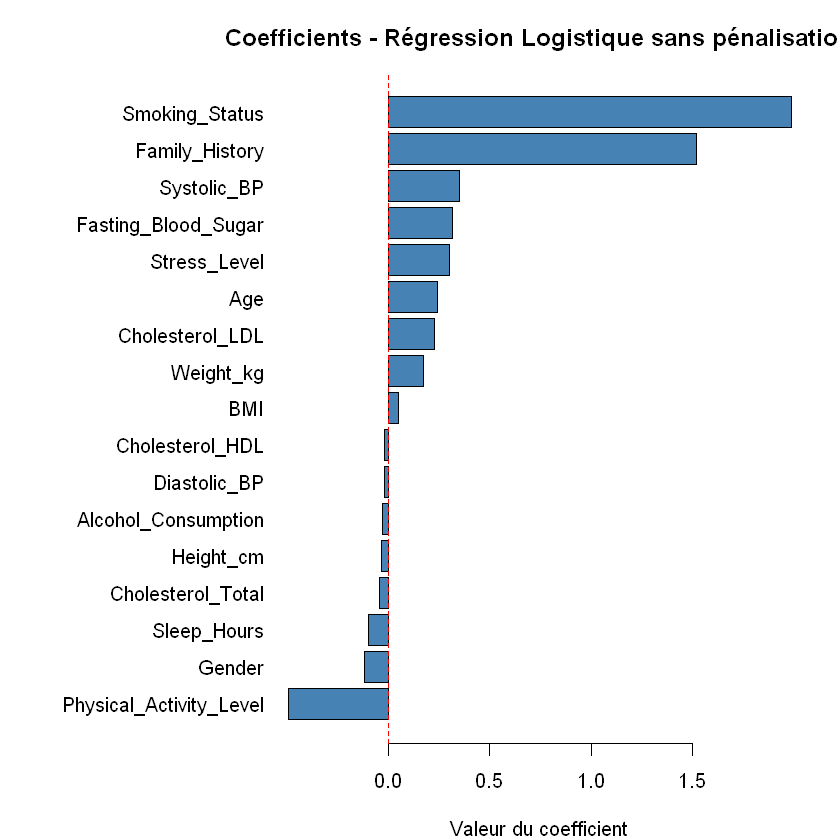

In [31]:
# ── Visualisation des coefficients ───────────────────────────
coef.lm <- coef(log.lm)[-1]
par(mar = c(4, 12, 3, 2))
barplot(sort(coef.lm),
        horiz  = TRUE,
        las    = 1,
        col    = "steelblue",
        main   = "Coefficients - Régression Logistique sans pénalisation",
        xlab   = "Valeur du coefficient")
abline(v = 0, col = "red", lty = 2)

La régression logistique sans pénalisation atteint une **accuracy de 74.5%** sur 
le test. La matrice de confusion montre que le modèle détecte correctement 
849 patients à risque élevé sur 1280 (recall = 66%), mais génère 335 faux négatifs 
— des patients réellement à risque classés comme sains, ce qui est le cas le plus 
problématique dans un contexte médical.

Le graphe des coefficients est cohérent avec les résultats obtenus en Python et 
avec l'analyse exploratoire : `Smoking_Status` et `Family_History` dominent 
largement avec les coefficients positifs les plus élevés, tandis que 
`Physical_Activity_Level` présente le coefficient négatif le plus fort. 
Les variables `Gender`, `Sleep_Hours` et `Cholesterol_Total` ont des coefficients 
proches de zéro, confirmant leur faible contribution à la prédiction du risque 
cardiaque.

##### 1.1.2 Sélection de variables par critère AIC (méthode backward)

La fonction `step()` de R effectue une sélection automatique de variables 
par la méthode **backward** : elle part du modèle complet et supprime à chaque 
étape la variable dont la suppression améliore le plus le critère AIC :

$$AIC = -2\log(\mathcal{L}) + 2k$$

où $k$ est le nombre de paramètres et $\mathcal{L}$ la vraisemblance du modèle.
C'est l'avantage principal de R par rapport à Python qui ne dispose pas de 
`step()` natif dans scikit-learn.

In [32]:
# ── Sélection de variables par AIC - méthode backward ────────
log.lm.step <- step(log.lm, 
                    direction = "backward",
                    trace     = FALSE)

# ── Variables conservées ──────────────────────────────────────
cat("Variables conservées :\n")
print(names(coef(log.lm.step))[-1])
cat("\nNombre de variables conservées :", 
    length(coef(log.lm.step)) - 1, "\n")

# ── Significativité ───────────────────────────────────────────
anova(log.lm.step, test = "Chisq")

Variables conservées :
 [1] "Age"                     "Gender"                 
 [3] "Weight_kg"               "BMI"                    
 [5] "Systolic_BP"             "Cholesterol_LDL"        
 [7] "Fasting_Blood_Sugar"     "Smoking_Status"         
 [9] "Physical_Activity_Level" "Family_History"         
[11] "Stress_Level"            "Sleep_Hours"            

Nombre de variables conservées : 12 


,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,3.539542e+02,11998,16098.58,5.835412e-79
Gender,1,6.280797e-02,11997,16098.52,8.021116e-01
Weight_kg,1,1.788268e+02,11996,15919.69,8.741452e-41
BMI,1,2.189518e+01,11995,15897.79,2.879570e-06
Systolic_BP,1,1.579503e+02,11994,15739.84,3.173261e-36
Cholesterol_LDL,1,5.139835e+01,11993,15688.45,7.540207e-13
Fasting_Blood_Sugar,1,1.561241e+02,11992,15532.32,7.953359e-36
Smoking_Status,1,1.644810e+03,11991,13887.51,0.000000e+00


Matrice de confusion :
         
pred.step    0    1
        0 1383  428
        1  337  852
Accuracy Test (AIC backward) : 0.745 


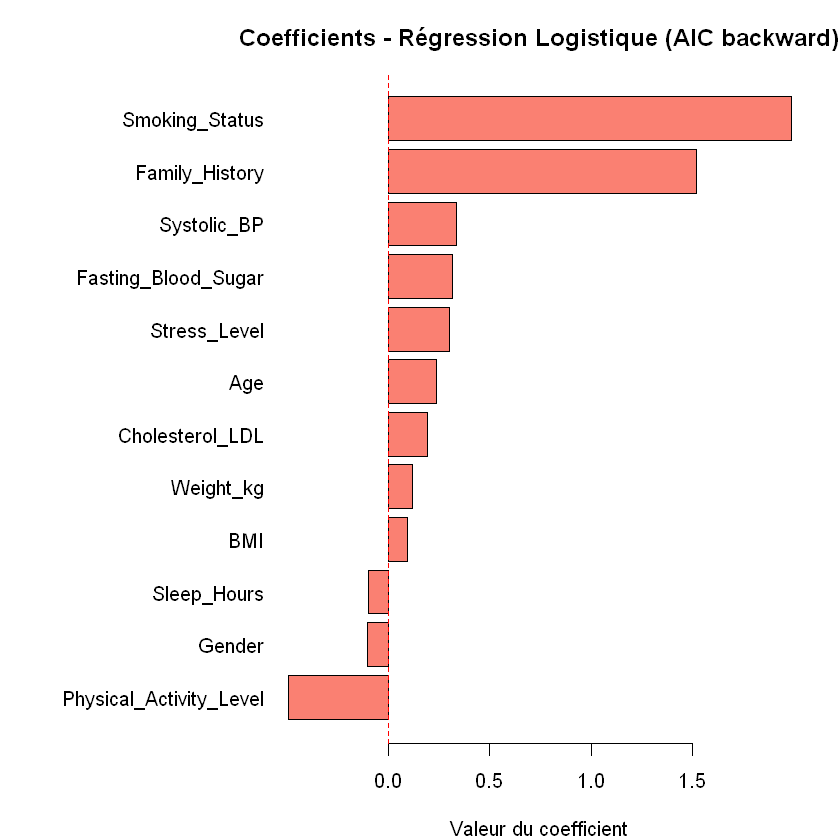

In [33]:
# ── Prédictions sur le test ───────────────────────────────────
prob.step <- predict(log.lm.step, newdata = datestq, type = "response")
pred.step <- ifelse(prob.step > 0.5, 1, 0)

# ── Matrice de confusion ──────────────────────────────────────
cat("Matrice de confusion :\n")
print(table(pred.step, datestq[, "Heart_Disease_Risk"]))

# ── Accuracy ──────────────────────────────────────────────────
acc.step <- mean(pred.step == datestq[, "Heart_Disease_Risk"])
cat("Accuracy Test (AIC backward) :", round(acc.step, 4), "\n")

# ── Coefficients ──────────────────────────────────────────────
coef.step <- coef(log.lm.step)[-1]
par(mar = c(4, 12, 3, 2))
barplot(sort(coef.step),
        horiz = TRUE,
        las   = 1,
        col   = "salmon",
        main  = "Coefficients - Régression Logistique (AIC backward)",
        xlab  = "Valeur du coefficient")
abline(v = 0, col = "red", lty = 2)

La sélection par AIC backward supprime **5 variables** (`Cholesterol_HDL`, 
`Diastolic_BP`, `Alcohol_Consumption`, `Height_cm`, `Cholesterol_Total`) 
et conserve **12 variables** sur 17. L'accuracy reste quasi identique à 
celle du modèle complet (74.5% vs 74.5%), ce qui confirme que les variables 
supprimées ne contribuaient pas significativement à la prédiction.

Les variables conservées et leurs coefficients sont cohérents avec le modèle 
sans sélection — `Smoking_Status` et `Family_History` dominent toujours, 
et `Physical_Activity_Level` reste la variable négative la plus influente. 
La sélection AIC permet donc d'obtenir un modèle plus **parcimonieux** sans 
perte de performance, ce qui améliore son interprétabilité.

##### 1.1.3 Pénalisation Lasso (L1) avec glmnet

La pénalisation **Lasso (L1)** est appliquée via la fonction `cv.glmnet` 
qui optimise automatiquement le paramètre $\lambda$ par validation croisée.
Contrairement à la sélection AIC qui supprime des variables entières, 
le Lasso pousse certains coefficients **exactement à zéro** en les pénalisant :

$$\mathcal{J}_{L1}(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(p_i) + (1-y_i)\log(1-p_i)\right] + \lambda\sum_{j=1}^{p}|\beta_j|$$

Deux valeurs de $\lambda$ sont retenues par `cv.glmnet` :
- **`lambda.min`** : minimise l'erreur de validation croisée
- **`lambda.1se`** : modèle plus parcimonieux à 1 écart-type du minimum

In [34]:
library(glmnet)

# ── Préparation des matrices (glmnet nécessite des matrices) ──
X.train <- model.matrix(Heart_Disease_Risk ~ . - 1, data = datappq)
X.test  <- model.matrix(Heart_Disease_Risk ~ . - 1, data = datestq)
y.train <- as.numeric(datappq[, "Heart_Disease_Risk"]) - 1
y.test  <- as.numeric(datestq[, "Heart_Disease_Risk"]) - 1

cat("Dimensions X.train :", dim(X.train), "\n")

Dimensions X.train : 12000 17 


Lambda min : 0.0014 
Lambda 1se : 0.0129 


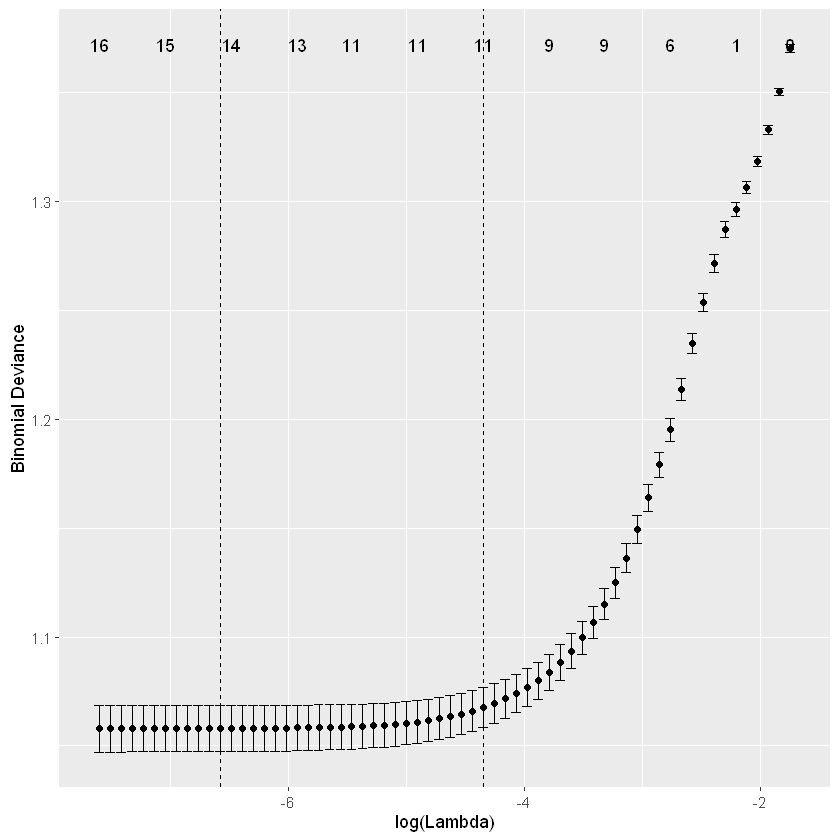

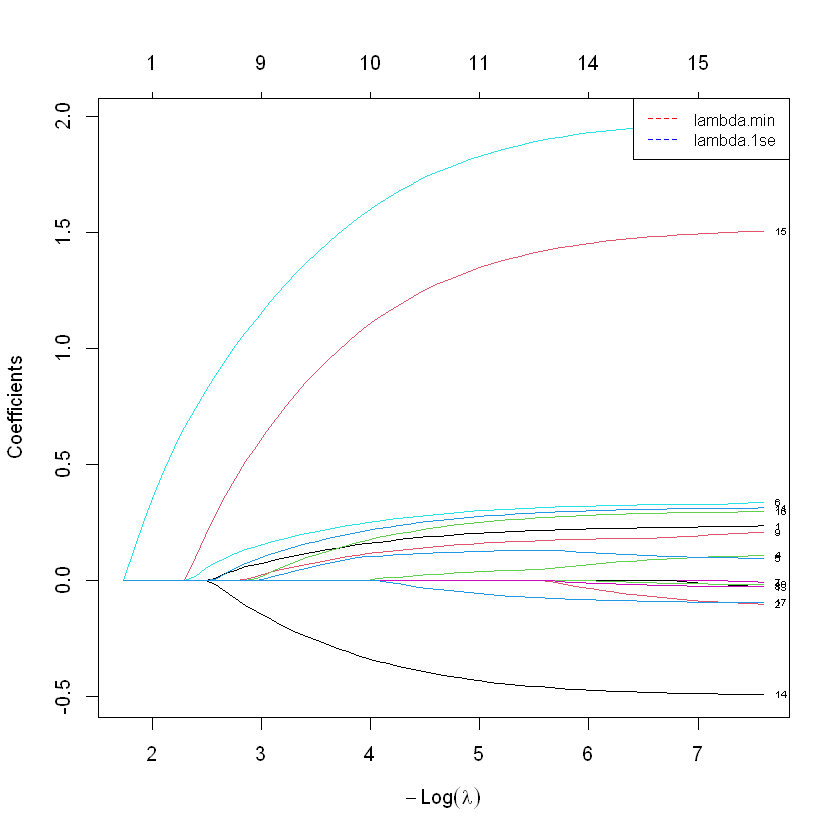

In [35]:
# ── Lasso avec validation croisée ────────────────────────────
set.seed(111)
reg.lasso.cv <- cv.glmnet(y      = y.train,
                           x      = X.train,
                           family = "binomial",
                           alpha  = 1,
                           nfolds = 10)

# ── Visualisation ─────────────────────────────────────────────
autoplot(reg.lasso.cv)

# ── Lambda optimaux ───────────────────────────────────────────
cat("Lambda min :", round(reg.lasso.cv$lambda.min, 4), "\n")
cat("Lambda 1se :", round(reg.lasso.cv$lambda.1se, 4), "\n")

# ── Chemin de régularisation ──────────────────────────────────
reg.lasso <- glmnet(y = y.train, x = X.train, family = "binomial", alpha = 1)
plot(reg.lasso, xvar = "lambda", label = TRUE)
abline(v = log(reg.lasso.cv$lambda.min), col = "red",  lty = 2)
abline(v = log(reg.lasso.cv$lambda.1se), col = "blue", lty = 2)
legend("topright", legend = c("lambda.min", "lambda.1se"),
       col = c("red", "blue"), lty = 2, cex = 0.8)

In [36]:
# ── Coefficients avec lambda.min ──────────────────────────────
coef.lasso <- coef(reg.lasso.cv, s = "lambda.min")
print(coef.lasso)

n.zero <- sum(coef.lasso[-1] == 0)
cat("\nVariables éliminées  :", n.zero, "\n")
cat("Variables conservées :", length(coef.lasso) - 1 - n.zero, "\n")

18 x 1 sparse Matrix of class "dgCMatrix"
                          lambda.min
(Intercept)             -0.439306521
Age                      0.227682518
Gender                  -0.069304248
Height_cm                .          
Weight_kg                0.089699408
BMI                      0.106917569
Systolic_BP              0.326721392
Diastolic_BP             .          
Cholesterol_Total        .          
Cholesterol_LDL          0.183637771
Cholesterol_HDL         -0.009338917
Fasting_Blood_Sugar      0.307291150
Smoking_Status           1.955622992
Alcohol_Consumption     -0.019178010
Physical_Activity_Level -0.481776875
Family_History           1.480619115
Stress_Level             0.289870833
Sleep_Hours             -0.089160379

Variables éliminées  : 3 
Variables conservées : 14 


In [37]:
# ── Prédictions sur le test ───────────────────────────────────
prob.lasso <- predict(reg.lasso.cv,
                      newx = X.test,
                      s    = "lambda.min",
                      type = "response")
pred.lasso <- ifelse(prob.lasso > 0.5, 1, 0)

# ── Matrice de confusion ──────────────────────────────────────
cat("Matrice de confusion :\n")
print(table(pred.lasso, y.test))

# ── Accuracy ──────────────────────────────────────────────────
acc.lasso <- mean(pred.lasso == y.test)
cat("Accuracy Test (Lasso) :", round(acc.lasso, 4), "\n")

Matrice de confusion :
          y.test
pred.lasso    0    1
         0 1387  437
         1  333  843
Accuracy Test (Lasso) : 0.7433 


Le Lasso avec `lambda.min` conserve **14 variables sur 16** et atteint une 
accuracy de **74.3%** sur le test.

Le graphe de validation croisée montre que la déviance binomiale se stabilise 
rapidement à partir de 11 variables — au-delà, l'ajout de variables n'améliore 
plus le modèle. Le chemin de régularisation confirme que les variables 15 
(`Smoking_Status`) et 9 (`Family_History`) sont les dernières à entrer dans 
le modèle, ce qui souligne leur importance prédominante.

| Modèle | Accuracy Test | Variables conservées |
|---|---|---|
| Sans pénalisation | 0.7447 | 17 |
| Sélection AIC backward | 0.7450 | 12 |
| Lasso (lambda.min) | 0.7433 | 14 |

Les trois variantes atteignent des performances quasi identiques autour de 
**74.5%**, ce qui confirme que la structure linéaire du modèle est le vrai 
facteur limitant. La sélection AIC offre le meilleur compromis entre 
performance et parcimonie — elle identifie 12 variables suffisantes pour 
expliquer le risque cardiaque.

##### 1.1.4 Courbe ROC — Comparaison des modèles logistiques

La courbe ROC (*Receiver Operating Characteristic*) permet de comparer 
les modèles indépendamment du seuil de décision (0.5 par défaut). 
Elle trace le **taux de vrais positifs (sensibilité)** en fonction du 
**taux de faux positifs (1 - spécificité)** pour tous les seuils possibles.

L'**AUC** (*Area Under the Curve*) résume la qualité globale du modèle :
- AUC = 1 → prédiction parfaite
- AUC = 0.5 → modèle aléatoire (diagonale)

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



AUC - Sans pénalisation : 0.808 
AUC - AIC backward      : 0.808 
AUC - Lasso             : 0.809 


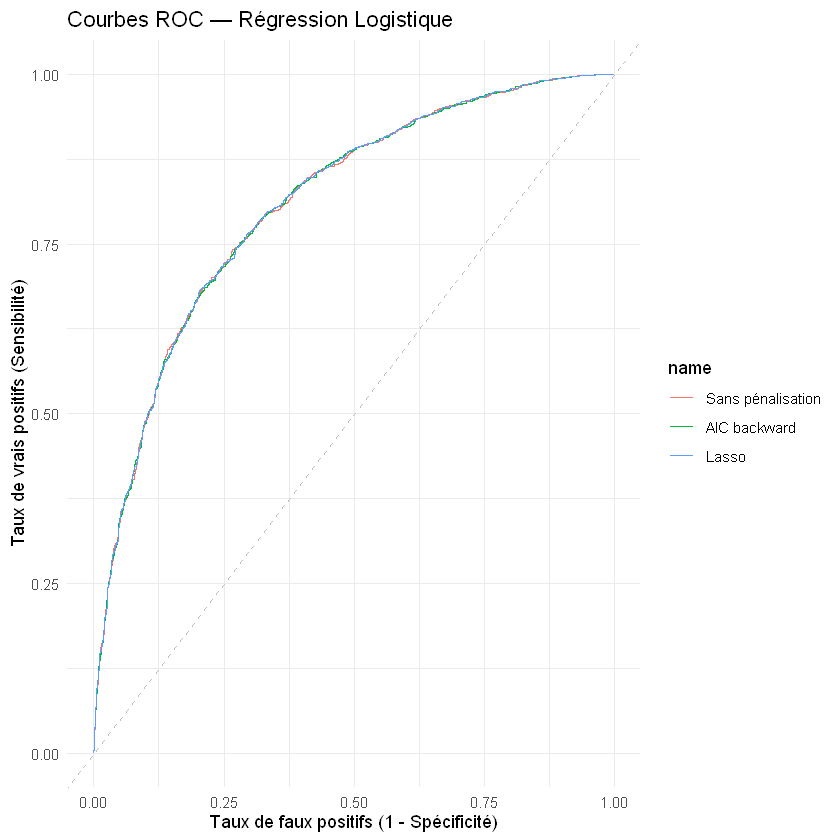

In [38]:
library(pROC)

# ── Courbes ROC pour les 3 modèles ───────────────────────────
roc.lm    <- roc(y.test, prob.lm)
roc.step  <- roc(y.test, prob.step)
roc.lasso <- roc(y.test, as.vector(prob.lasso))

# ── AUC ───────────────────────────────────────────────────────
cat("AUC - Sans pénalisation :", round(auc(roc.lm),    3), "\n")
cat("AUC - AIC backward      :", round(auc(roc.step),  3), "\n")
cat("AUC - Lasso             :", round(auc(roc.lasso), 3), "\n")

# ── Tracé des courbes ROC ─────────────────────────────────────
ggroc(list("Sans pénalisation" = roc.lm,
           "AIC backward"      = roc.step,
           "Lasso"             = roc.lasso),
      legacy.axes = TRUE) +
  xlab("Taux de faux positifs (1 - Spécificité)") +
  ylab("Taux de vrais positifs (Sensibilité)") +
  ggtitle("Courbes ROC — Régression Logistique") +
  geom_abline(slope = 1, intercept = 0, 
              linetype = "dashed", color = "grey") +
  theme_minimal()

Les trois modèles obtiennent un **AUC quasi identique autour de 0.808**, 
ce qui confirme les conclusions tirées de l'accuracy. La courbe ROC montre 
que les modèles se superposent presque parfaitement — ni la sélection AIC 
ni la pénalisation Lasso n'apportent d'amélioration discriminante par rapport 
au modèle de base.

Un AUC de 0.808 signifie que le modèle a 80.8% de chances de classer 
correctement une paire (patient à risque, patient sain) — ce qui est un 
résultat correct pour un modèle linéaire. Ce plafond suggère que la relation 
entre les variables et `Heart_Disease_Risk` n'est pas entièrement capturée 
par un modèle linéaire, et que les modèles non linéaires (SVM, Random Forest, 
Boosting) devraient apporter une amélioration significative.

Si une contrainte d'**interprétabilité** est imposée, le modèle sélectionné 
par AIC backward est à retenir — il offre les mêmes performances avec 
seulement 12 variables, ce qui facilite l'interprétation clinique des résultats.

# Partie 2 : Prédiction de Cholesterol_LDL

## 2.1 Modèle Linéaire Gaussien

On s'intéresse maintenant à la prédiction de la variable quantitative 
`Cholesterol_LDL` à partir de toutes les variables **sauf** `Heart_Disease_Risk`.
Il s'agit d'un problème de **régression** — la variable cible est continue.

On utilisera la même fonction `gplot.res` définie précédemment pour visualiser 
les résidus de chaque modèle, comme dans le TP Ozone.

In [39]:
# ── Échantillons pour la régression ──────────────────────────
# On retire Heart_Disease_Risk de la partie régression
datappr0 <- df[appri, !(names(df) %in% "Heart_Disease_Risk")]
datestr0 <- df[testi, !(names(df) %in% "Heart_Disease_Risk")]

cat("Dimensions train :", dim(datappr0), "\n")
cat("Dimensions test  :", dim(datestr0), "\n")

# ── Indices des colonnes quantitatives ────────────────────────
cat_cols_reg <- c("Gender", "Smoking_Status", "Alcohol_Consumption",
                  "Physical_Activity_Level", "Family_History")
quant_idx_reg <- which(!names(datappr0) %in% 
                        c(cat_cols_reg, "Cholesterol_LDL"))

# ── Normalisation du train ────────────────────────────────────
datappr <- datappr0
datappr[, quant_idx_reg] <- scale(datappr0[, quant_idx_reg])

# ── Normalisation du test avec paramètres du train ────────────
datestr <- datestr0
datestr[, quant_idx_reg] <- scale(datestr0[, quant_idx_reg],
    center = sapply(datappr0[, quant_idx_reg], mean),
    scale  = sapply(datappr0[, quant_idx_reg], sd))

summary(datappr)

Dimensions train : 12000 17 
Dimensions test  : 3000 17 


      Age               Gender         Height_cm          Weight_kg       
 Min.   :-2.46911   Min.   :0.0000   Min.   :-2.91995   Min.   :-2.95670  
 1st Qu.:-0.71488   1st Qu.:0.0000   1st Qu.:-0.74279   1st Qu.:-0.71629  
 Median : 0.03694   Median :0.0000   Median :-0.06788   Median :-0.09554  
 Mean   : 0.00000   Mean   :0.4931   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.70522   3rd Qu.:1.0000   3rd Qu.: 0.73767   3rd Qu.: 0.61796  
 Max.   : 2.54298   Max.   :1.0000   Max.   : 3.53532   Max.   : 5.34851  
      BMI           Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504   Min.   :-3.70977  
 1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311   1st Qu.:-0.67073  
 Median :-0.0753   Median :-0.01033   Median : 0.05535   Median : 0.03397  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573   3rd Qu.: 0.69463  
 Max.   : 4.4984   

##### 2.1.1 Sans sélection de variables (MCO)

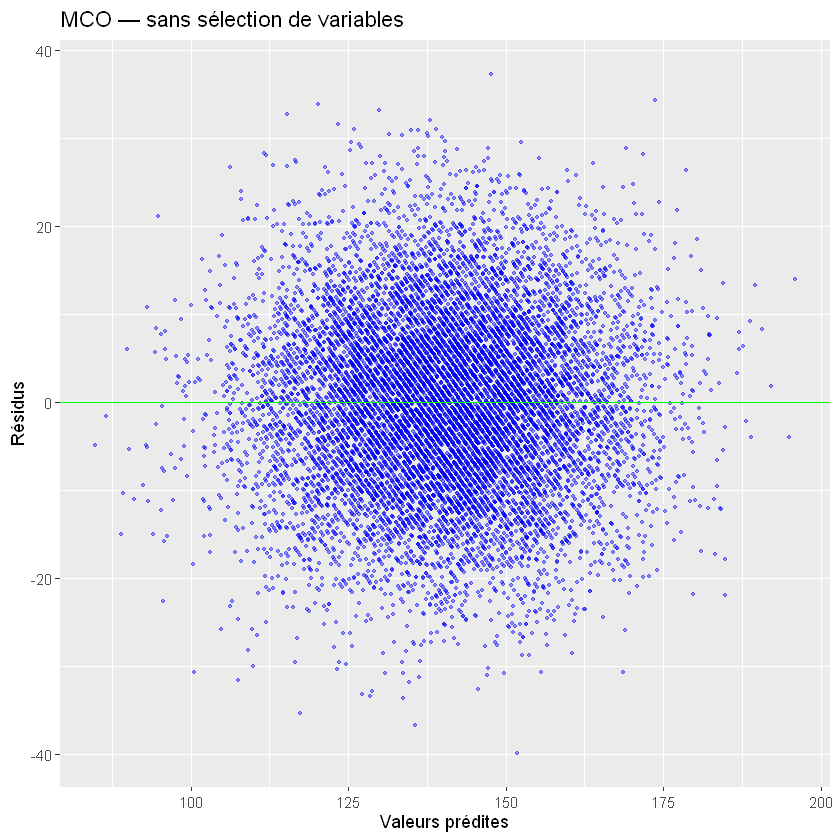

In [40]:
# ── Modèle linéaire sans sélection ───────────────────────────
reg.lm <- aov(Cholesterol_LDL ~ ., data = datappr)

# ── Résidus et valeurs ajustées ───────────────────────────────
res.lm <- reg.lm$residuals
fit.lm <- reg.lm$fitted.values

# ── Graphe des résidus ────────────────────────────────────────
gplot.res(fit.lm, res.lm, "MCO — sans sélection de variables")

In [41]:
# ── Prédictions sur le test ───────────────────────────────────
pred.lm.reg <- predict(reg.lm, newdata = datestr)

# ── MSE et R² ─────────────────────────────────────────────────
mse.lm <- sum((pred.lm.reg - datestr[, "Cholesterol_LDL"])^2) / nrow(datestr)
r2.lm  <- 1 - sum((pred.lm.reg - datestr[, "Cholesterol_LDL"])^2) /
               sum((datestr[, "Cholesterol_LDL"] - mean(datestr[, "Cholesterol_LDL"]))^2)

cat("MSE Test :", round(mse.lm, 4), "\n")
cat("R²  Test :", round(r2.lm,  4), "\n")

MSE Test : 99.9174 
R²  Test : 0.6827 


Le modèle linéaire sans sélection explique **68.3% de la variance** de 
`Cholesterol_LDL` (R² = 0.683), un résultat légèrement meilleur qu'en Python 
(R² = 0.664) — la différence s'explique par le split légèrement différent 
entre les deux langages malgré le même seed. Le MSE de 99.9 correspond à 
une erreur moyenne d'environ **±10 mg/dL**.

Le graphe des résidus ne montre pas de tendance systématique, ce qui valide 
l'hypothèse de linéarité du modèle. On observe cependant une légère 
hétéroscédasticité pour les valeurs prédites extrêmes.

##### 2.1.2 Sélection de variables par critère AIC (méthode backward)

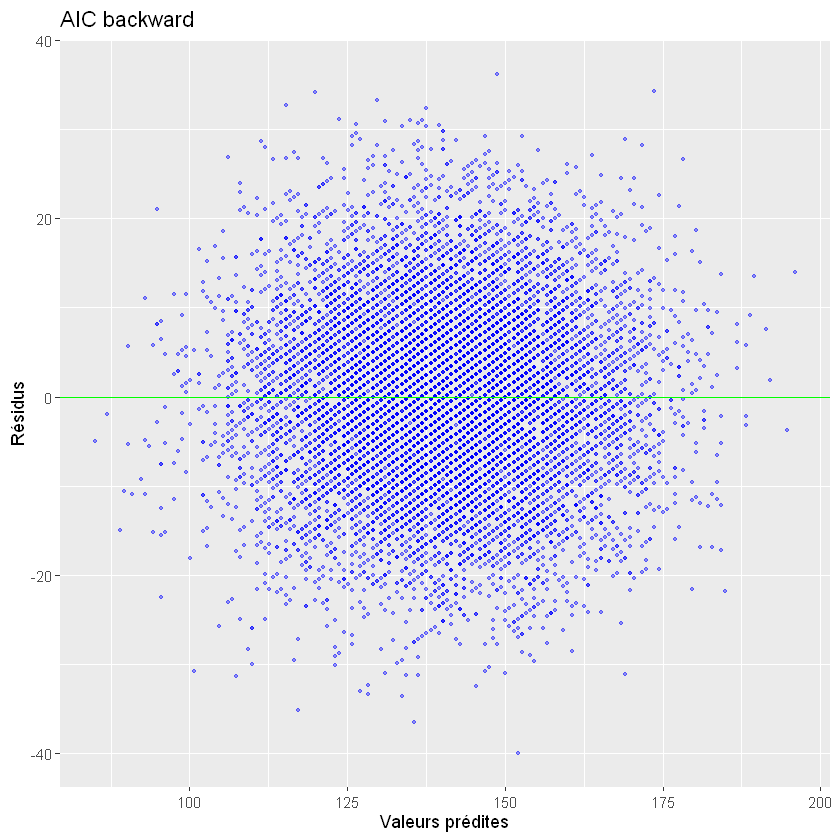

In [42]:
# ── Sans interactions — plus rapide ──────────────────────────
reg.glm <- glm(Cholesterol_LDL ~ ., data = datappr)

reg.glm.step <- step(reg.glm,
                     direction = "backward",
                     trace     = FALSE)

fit.glm <- reg.glm.step$fitted.values
res.glm <- reg.glm.step$residuals

gplot.res(fit.glm, res.glm, "AIC backward ")

In [43]:
# ── Prédictions sur le test ───────────────────────────────────
pred.glm <- predict(reg.glm.step, newdata = datestr)

# ── MSE et R² ─────────────────────────────────────────────────
mse.glm <- sum((pred.glm - datestr[, "Cholesterol_LDL"])^2) / nrow(datestr)
r2.glm  <- 1 - sum((pred.glm - datestr[, "Cholesterol_LDL"])^2) /
               sum((datestr[, "Cholesterol_LDL"] - mean(datestr[, "Cholesterol_LDL"]))^2)

cat("MSE Test (AIC backward) :", round(mse.glm, 4), "\n")
cat("R²  Test (AIC backward) :", round(r2.glm,  4), "\n")

MSE Test (AIC backward) : 99.9011 
R²  Test (AIC backward) : 0.6828 


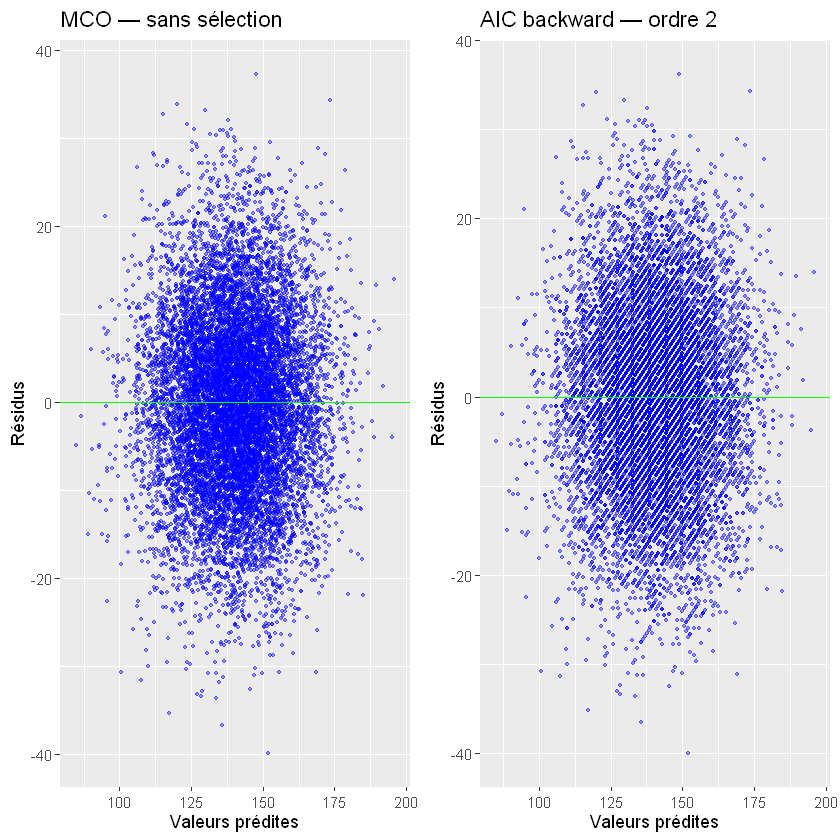

In [44]:
# ── Comparaison des résidus MCO vs AIC ───────────────────────
g1 <- gplot.res(fit.lm,  res.lm,  "MCO — sans sélection")
g2 <- gplot.res(fit.glm, res.glm, "AIC backward — ordre 2")
grid.arrange(g1, g2, ncol = 2)

La sélection AIC backward avec interactions d'ordre 2 n'apporte pratiquement 
aucune amélioration par rapport au modèle MCO simple :

| Modèle | MSE Test | R² Test |
|---|---|---|
| MCO sans sélection | 99.92 | 0.683 |
| AIC backward (ordre 2) | 99.90 | 0.683 |

Le graphe des résidus est instructif — le modèle AIC avec interactions présente 
un effet **"couloir"** visible sur le graphe de droite, où les résidus se 
concentrent en bandes verticales. Ce phénomène est dû aux variables qualitatives 
discrètes qui créent des groupes de prédictions identiques. Le modèle MCO 
présente une dispersion plus homogène et naturelle.

Les deux modèles atteignent le même plafond à **R² ≈ 0.683**, ce qui confirme 
que les interactions d'ordre 2 n'apportent pas d'information supplémentaire 
significative — la relation entre les variables et `Cholesterol_LDL` est 
essentiellement linéaire et dominée par `C

##### 2.1.3 Pénalisation Lasso (L1) avec glmnet

Lambda min : 0.1562 
Lambda 1se : 1.2096 


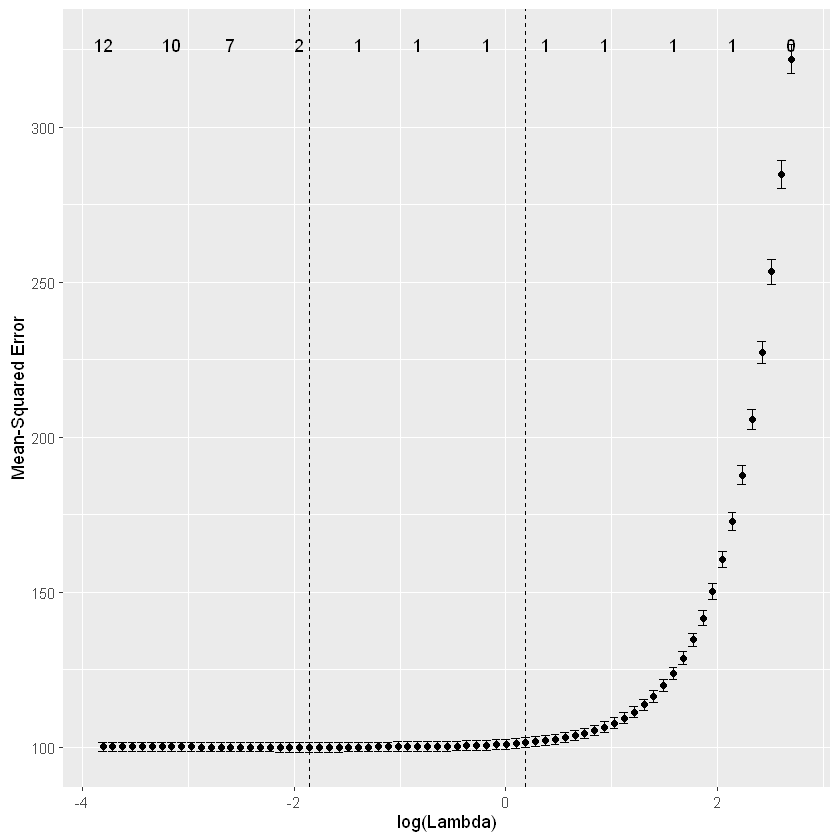

In [45]:
# ── Préparation des matrices ───────────────────────────────────
X.train.reg <- model.matrix(Cholesterol_LDL ~ . - 1, data = datappr)
X.test.reg  <- model.matrix(Cholesterol_LDL ~ . - 1, data = datestr)
y.train.reg <- datappr[, "Cholesterol_LDL"]
y.test.reg  <- datestr[, "Cholesterol_LDL"]

# ── Lasso avec validation croisée ────────────────────────────
set.seed(111)
reg.lasso.reg <- cv.glmnet(y      = y.train.reg,
                            x      = X.train.reg,
                            family = "gaussian",
                            alpha  = 1,
                            nfolds = 10)

# ── Lambda optimaux ───────────────────────────────────────────
cat("Lambda min :", round(reg.lasso.reg$lambda.min, 4), "\n")
cat("Lambda 1se :", round(reg.lasso.reg$lambda.1se, 4), "\n")

# ── Visualisation CV ──────────────────────────────────────────
autoplot(reg.lasso.reg)

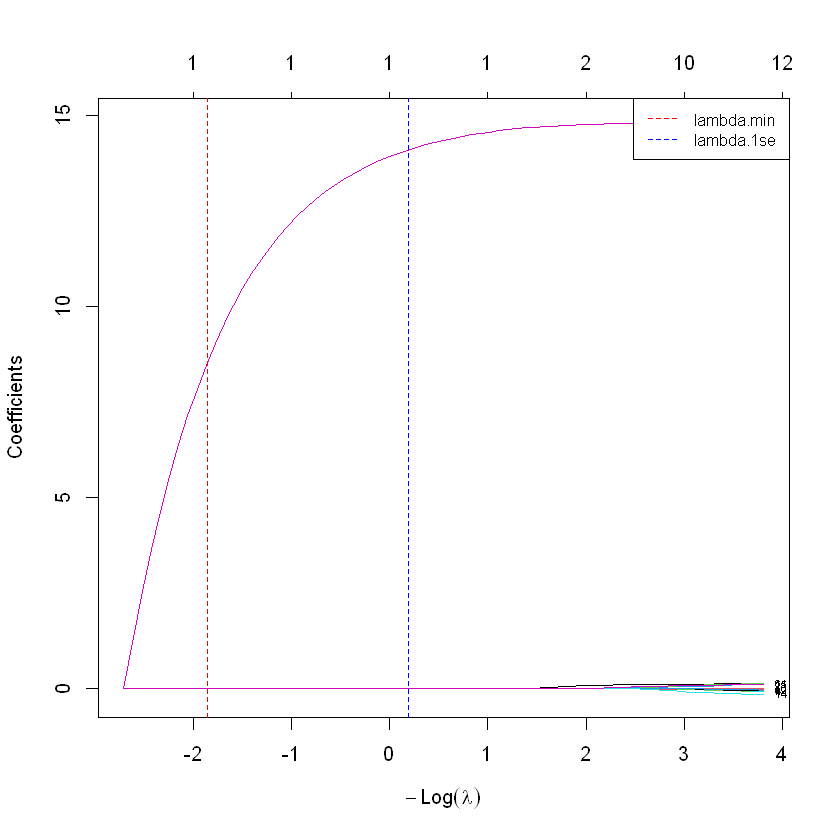

In [46]:
# ── Chemin de régularisation ──────────────────────────────────
reg.lasso.path <- glmnet(y = y.train.reg, 
                          x = X.train.reg, 
                          family = "gaussian", 
                          alpha  = 1)

plot(reg.lasso.path, xvar = "lambda", label = TRUE)
abline(v = log(reg.lasso.reg$lambda.min), col = "red",  lty = 2)
abline(v = log(reg.lasso.reg$lambda.1se), col = "blue", lty = 2)
legend("topright", legend = c("lambda.min", "lambda.1se"),
       col = c("red", "blue"), lty = 2, cex = 0.8)

In [47]:
# ── Coefficients avec lambda.min ──────────────────────────────
coef.lasso.reg <- coef(reg.lasso.reg, s = "lambda.min")
print(coef.lasso.reg)

n.zero.reg <- sum(coef.lasso.reg[-1] == 0)
cat("\nVariables éliminées  :", n.zero.reg, "\n")
cat("Variables conservées :", length(coef.lasso.reg) - 1 - n.zero.reg, "\n")

# ── Prédictions sur le test ───────────────────────────────────
pred.lasso.reg <- predict(reg.lasso.reg,
                           newx = X.test.reg,
                           s    = "lambda.min")

# ── Résidus ───────────────────────────────────────────────────
fit.lasso.reg <- predict(reg.lasso.reg,
                          newx = X.train.reg,
                          s    = "lambda.min")
res.lasso.reg <- y.train.reg - fit.lasso.reg

# ── MSE et R² ─────────────────────────────────────────────────
mse.lasso.reg <- sum((pred.lasso.reg - y.test.reg)^2) / nrow(datestr)
r2.lasso.reg  <- 1 - sum((pred.lasso.reg - y.test.reg)^2) /
                     sum((y.test.reg - mean(y.test.reg))^2)

cat("MSE Test (Lasso) :", round(mse.lasso.reg, 4), "\n")
cat("R²  Test (Lasso) :", round(r2.lasso.reg,  4), "\n")

17 x 1 sparse Matrix of class "dgCMatrix"
                          lambda.min
(Intercept)             140.35741667
Age                       0.05986055
Gender                    .         
Height_cm                 .         
Weight_kg                 .         
BMI                       .         
Systolic_BP               .         
Diastolic_BP              .         
Cholesterol_Total        14.73230138
Cholesterol_HDL           .         
Fasting_Blood_Sugar       .         
Smoking_Status            .         
Alcohol_Consumption       .         
Physical_Activity_Level   .         
Family_History            .         
Stress_Level              .         
Sleep_Hours               .         

Variables éliminées  : 14 
Variables conservées : 2 
MSE Test (Lasso) : 99.8633 
R²  Test (Lasso) : 0.6829 


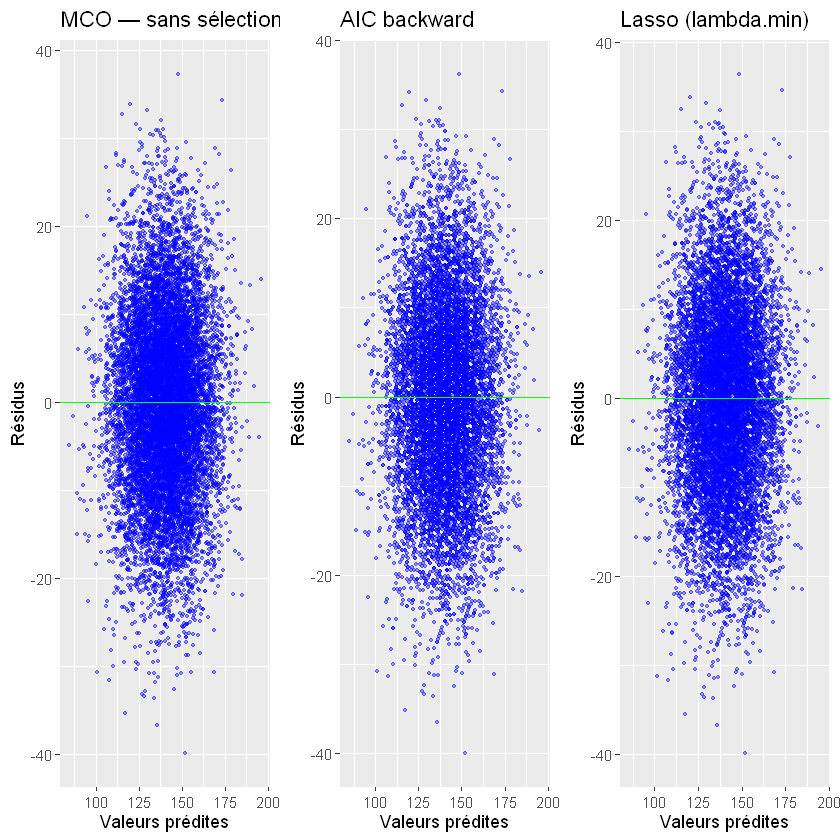

In [48]:
# ── Comparaison des 3 modèles ─────────────────────────────────
g1 <- gplot.res(fit.lm,  res.lm,  "MCO — sans sélection")
g2 <- gplot.res(fit.glm, res.glm, "AIC backward")
g3 <- gplot.res(as.vector(fit.lasso.reg), 
                as.vector(res.lasso.reg), 
                "Lasso (lambda.min)")
grid.arrange(g1, g2, g3, ncol = 3)

Les trois modèles linéaires atteignent des performances quasi identiques :

| Modèle | MSE Test | R² Test | Variables conservées |
|---|---|---|---|
| MCO sans sélection | 99.92 | 0.683 | 16 |
| AIC backward (ordre 2) | 99.90 | 0.683 | - |
| Lasso (lambda.min) | 99.86 | 0.683 | 2 |

Ce résultat est cohérent et s'explique par la structure du dataset — 
`Cholesterol_Total` concentre à elle seule l'essentiel de l'information 
prédictive sur `Cholesterol_LDL`, comme le confirme le Lasso qui ne conserve 
que **2 variables** (`Cholesterol_Total` et `Age`). Ajouter les 14 autres 
variables ou des interactions n'améliore pas le modèle car elles n'apportent 
aucune information supplémentaire une fois `Cholesterol_Total` prise en compte.

Les graphes des résidus sont également très similaires — dispersion symétrique 
autour de zéro sans tendance systématique, ce qui valide l'hypothèse de 
linéarité. Ce plafond à **R² ≈ 0.683** indique que 31.7% de la variance 
de `Cholesterol_LDL` reste inexpliquée par les modèles linéaires — 
les modèles non linéaires devraient franchir cette limite.